# CSE 4836 - Pattern Recognition Lab 03


# Introduction

In this lab, you will investigate what fully connected neural networks learn on CIFAR-10 and how gradients move through those networks. You will begin with the single class templates learned by a linear classifier, inspect hidden-neuron features across neural-network layers, compare networks with different depth and width, visualize backpropagation through a small computation graph, and diagnose gradient flow in real CIFAR-10 networks.

Most training, data-loading, and plotting code is provided. Your code changes are intentionally small. Your main responsibility is to run controlled experiments, inspect the generated visualizations, and explain what evidence they provide about representations and optimization.


# Setup


In [1]:
from pathlib import Path

DATA_DIR = Path("datasets")
OUTPUT_DIR = Path("lab03_outputs")
CIFAR10_DIR = DATA_DIR / "cifar10"

print(f"Data directory: {CIFAR10_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


Data directory: datasets/cifar10
Output directory: lab03_outputs


# Import Libraries and Configure the Experiment


In [2]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms

from IPython.display import Image, display
from torch.nn import Module
from torch.utils.data import DataLoader, Subset
from torchviz import make_dot
from torchvision.datasets import ImageFolder

GLOBAL_SEED = 0
CIFAR10_CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


/mnt/Work/Environments/Ubuntu/Conda/envs/ml/lib/python3.11/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using device: cuda


# Shared CIFAR-10 Components

These components follow the same interfaces used in Lab 02. `LinearClassifier` produces one score per class, `AccuracyAnalyzer` evaluates predictions, and `run_gradient_descent_optimizer` performs the repeated training steps. The helpers are provided so later cells can focus on model behavior rather than boilerplate.


## Reproducibility Helpers

`set_seed` controls Python, NumPy, CPU, CUDA, and data-loader randomness so controlled comparisons can be repeated.

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = False
    torch.use_deterministic_algorithms(False)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    random.seed(worker_seed)
    np.random.seed(worker_seed)


## `LinearClassifier`

`LinearClassifier` flattens each image and produces one class score from one learned weight template per class.

In [4]:
class LinearClassifier(Module):
    def __init__(self, n_features, n_classes, sigma=0.01):
        super().__init__()

        self.n_features = n_features
        self.n_classes = n_classes

        self.w = nn.Parameter(torch.randn(n_classes, n_features) * sigma)
        self.b = nn.Parameter(torch.zeros(n_classes))

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return x @ self.w.T + self.b

## Analyzer Classes

`ModelPerformanceAnalyzer` collects predictions from a data loader. `AccuracyAnalyzer` computes the fraction of correct predictions.

In [5]:
class ModelPerformanceAnalyzer:
    def test(self, model, testloader, device):
        model.eval()

        y_true = []
        y_pred = []

        with torch.no_grad():
            for x, y in testloader:
                x = x.to(device)
                y = y.to(device)

                scores = model(x)
                y_hat = torch.argmax(scores, dim=-1)

                y_true.append(y.cpu())
                y_pred.append(y_hat.cpu())

        y_true = torch.cat(y_true)
        y_pred = torch.cat(y_pred)

        return self.compute(y_true, y_pred)

    def compute(self, y_true, y_pred):
        raise NotImplementedError(f"{self.__class__.__name__}.compute() must be implemented")


class AccuracyAnalyzer(ModelPerformanceAnalyzer):
    def compute(self, y_true, y_pred):
        return (y_true == y_pred).float().mean().item()

## CIFAR-10 Loader

`load_cifar10` creates reproducible training and test loaders from the already-extracted local CIFAR-10 folder.


In [6]:
def load_cifar10(
    data_dir,
    batch_size,
    num_workers,
    seed,
    train_size=None,
    test_size=None,
):
    transform = transforms.ToTensor()
    generator = torch.Generator()
    generator.manual_seed(seed)

    dataset_dir = Path(data_dir) / "cifar10"
    train_dir = dataset_dir / "train"
    test_dir = dataset_dir / "test"

    if not train_dir.exists() or not test_dir.exists():
        raise FileNotFoundError(f"Expected CIFAR-10 ImageFolder data at {dataset_dir}")

    trainset = ImageFolder(root=train_dir, transform=transform)
    testset = ImageFolder(root=test_dir, transform=transform)

    if train_size is not None:
        trainset = Subset(trainset, range(min(train_size, len(trainset))))

    if test_size is not None:
        testset = Subset(testset, range(min(test_size, len(testset))))

    trainloader = DataLoader(
        trainset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        worker_init_fn=seed_worker,
        generator=generator,
    )
    testloader = DataLoader(
        testset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        worker_init_fn=seed_worker,
        generator=generator,
    )

    return trainloader, testloader


## Training Helper

`run_gradient_descent_optimizer` contains the repeated optimization boilerplate and returns the loss and test-accuracy history.

In [7]:
def run_gradient_descent_optimizer(
    model,
    trainloader,
    testloader,
    num_epochs,
    loss_fn,
    optimizer,
    analyzer,
    device,
):
    epoch_losses = []
    test_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for x, y in trainloader:
            x = x.to(device)
            y = y.to(device)

            scores = model(x)
            batch_loss = loss_fn(scores, y)

            optimizer.zero_grad()
            batch_loss.backward()
            optimizer.step()

            epoch_loss += batch_loss.item()

        epoch_loss /= len(trainloader)
        test_accuracy = analyzer.test(model, testloader, device)

        epoch_losses.append(epoch_loss)
        test_accuracies.append(test_accuracy)

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs}: "
            f"loss={epoch_loss:.4f}, test_accuracy={test_accuracy:.4f}"
        )

    return epoch_losses, test_accuracies

## Linear-Classifier Visualizers

These helpers normalize learned weights for display and plot training history. Plotting remains separate from model computation.

In [8]:
def normalize_image_for_display(image):
    image = image - image.min()
    image = image / image.max().clamp_min(1e-8)
    return image


def visualize_linear_templates(model, class_names, output_file):
    templates = model.w.detach().cpu().reshape(len(class_names), 3, 32, 32)

    figure, axes = plt.subplots(2, 5, figsize=(15, 8), layout="constrained")

    for class_id, axis in enumerate(axes.flat):
        template = normalize_image_for_display(templates[class_id])
        template = template.permute(1, 2, 0)

        axis.imshow(template)
        axis.set_title(class_names[class_id])
        axis.axis("off")

    figure.suptitle("One Learned Linear Template per CIFAR-10 Class", fontsize=18)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)


def visualize_training_history(epoch_losses, test_accuracies, output_file):
    epochs = range(1, len(epoch_losses) + 1)
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, epoch_losses, marker="o")
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].grid(alpha=0.25)

    axes[1].plot(epochs, test_accuracies, marker="o")
    axes[1].set_title("Test Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.25)

    figure.tight_layout()
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

In [9]:
set_seed(GLOBAL_SEED)
trainloader, testloader = load_cifar10(
    DATA_DIR,
    batch_size=512,
    num_workers=2,
    seed=GLOBAL_SEED,
)

# 01. Linear Classifier Templates

A linear classifier stores one weight vector for each CIFAR-10 class. Because each vector directly multiplies input pixels, it can be reshaped into a `3 x 32 x 32` image. The resulting image is one learned class template, not a collection of separate object-part detectors.

This section is a completed demonstration. Inspect the templates and use them as the baseline for the neural-network feature visualizations that follow.


## Prepare and Train the Linear Classifier


In [10]:
set_seed(GLOBAL_SEED)
linear_classifier = LinearClassifier(3 * 32 * 32, len(CIFAR10_CLASS_NAMES)).to(device)
linear_optimizer = torch.optim.SGD(
    linear_classifier.parameters(),
    lr=0.01,
    weight_decay=1e-4,
)
linear_losses, linear_accuracies = run_gradient_descent_optimizer(
    linear_classifier,
    trainloader,
    testloader,
    num_epochs=2,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer=linear_optimizer,
    analyzer=AccuracyAnalyzer(),
    device=device,
)

Epoch 01/2: loss=2.1229, test_accuracy=0.2905
Epoch 02/2: loss=1.9768, test_accuracy=0.3261


## Analyze Results


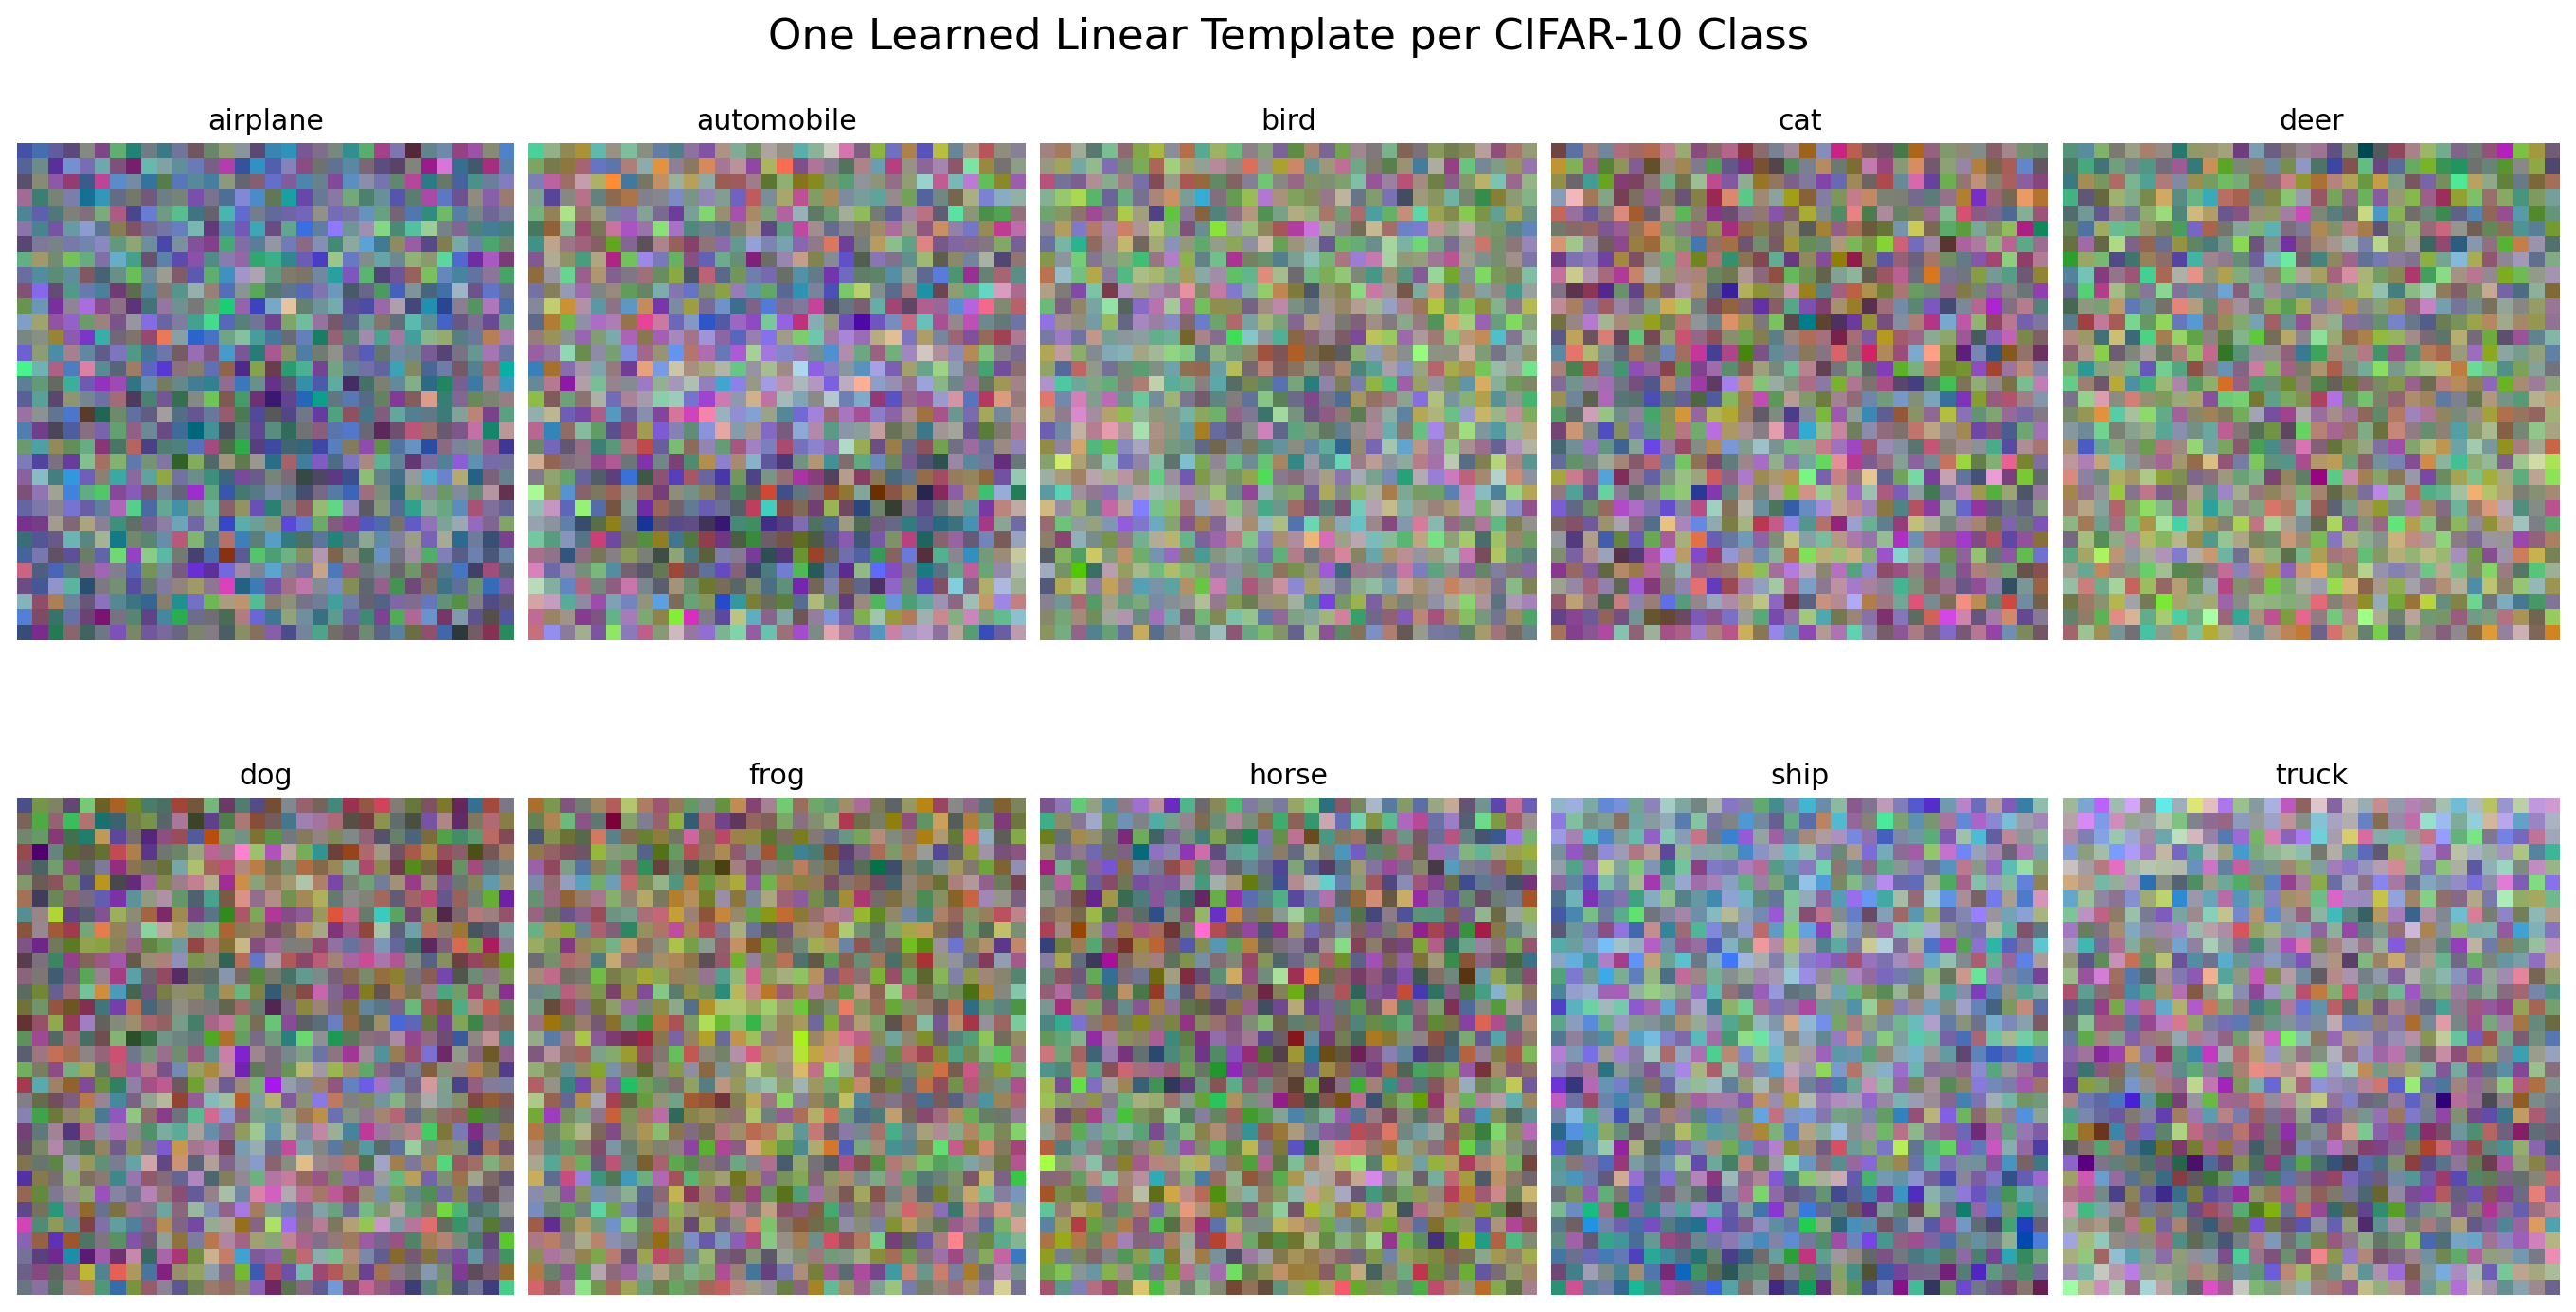

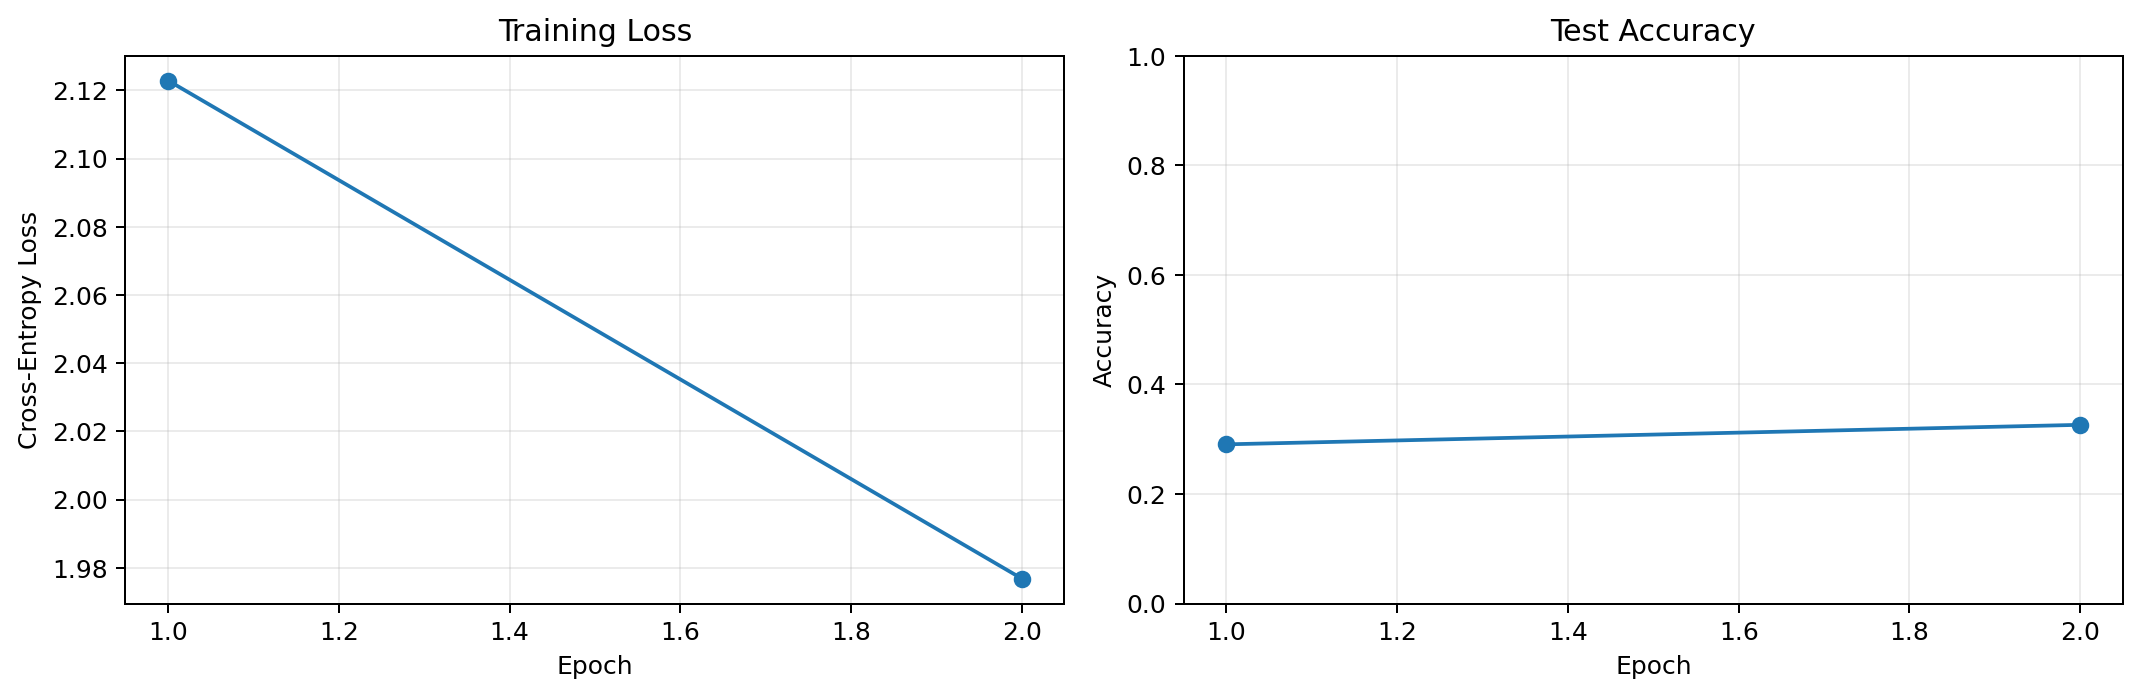

In [11]:
linear_output_dir = Path(OUTPUT_DIR) / "01_linear_classifier"
linear_output_dir.mkdir(parents=True, exist_ok=True)

visualize_linear_templates(
    linear_classifier,
    CIFAR10_CLASS_NAMES,
    linear_output_dir / "01_linear_class_templates.png",
)
visualize_training_history(
    linear_losses,
    linear_accuracies,
    linear_output_dir / "02_training_history.png",
)

display(Image(filename=linear_output_dir / "01_linear_class_templates.png"))
display(Image(filename=linear_output_dir / "02_training_history.png"))

# 02. Layerwise Features in a Neural Network

`NeuralNetwork` composes several `LinearClassifier` layers with ReLU activations. A first-layer neuron's weights still connect directly to pixels and can therefore be reshaped into an image. Deeper-layer weights connect to earlier neurons instead of pixels, so their behavior is visualized using the CIFAR-10 images that activate them most strongly.

`LayerActivationCollector` uses a forward hook to save one layer's activations. The remaining helpers select high-variance neurons, retrieve their top-activating images, and summarize their average activation by class.


## `NeuralNetwork`

`NeuralNetwork` builds a fully connected network from a list of hidden-layer sizes and applies ReLU after every hidden layer.

In [12]:
class NeuralNetwork(nn.Module):
    def __init__(self, n_features, n_classes, hidden_layer_sizes):
        super().__init__()

        layer_sizes = [n_features] + hidden_layer_sizes + [n_classes]

        self.layers = nn.ModuleList()
        for in_size, out_size in zip(layer_sizes[:-1], layer_sizes[1:]):
            self.layers.append(LinearClassifier(in_size, out_size))

    def forward(self, x):
        num_layers = len(self.layers)

        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i != num_layers - 1:
                x = torch.relu(x)

        return x


def unwrap_model(model):
    if isinstance(model, nn.DataParallel):
        return model.module
    return model

## `LayerActivationCollector`

`LayerActivationCollector` registers a forward hook on one layer and stores that layer's post-ReLU activations.

In [13]:
class LayerActivationCollector:
    def __init__(self, model, layer_id):
        self.activations = None
        layer = unwrap_model(model).layers[layer_id]
        self.handle = layer.register_forward_hook(self.save_activations)

    def save_activations(self, module, inputs, output):
        self.activations = torch.relu(output.detach())

    def remove(self):
        self.handle.remove()

## Neuron-Selection Helpers

These helpers select neurons with varied responses, retrieve their strongest activating images, and summarize their activation by class.

### `find_high_variance_neurons`

In [14]:
def find_high_variance_neurons(model, dataloader, layer_id, num_neurons, device):
    collector = LayerActivationCollector(model, layer_id)
    activation_sum = None
    activation_square_sum = None
    num_samples = 0

    model.eval()
    with torch.no_grad():
        for x, _ in dataloader:
            model(x.to(device, non_blocking=True))
            activations = collector.activations

            batch_sum = activations.sum(dim=0).cpu()
            batch_square_sum = activations.square().sum(dim=0).cpu()

            if activation_sum is None:
                activation_sum = batch_sum
                activation_square_sum = batch_square_sum
            else:
                activation_sum += batch_sum
                activation_square_sum += batch_square_sum

            num_samples += activations.shape[0]

    collector.remove()

    activation_mean = activation_sum / num_samples
    activation_variance = activation_square_sum / num_samples - activation_mean.square()
    return torch.topk(activation_variance, num_neurons).indices.tolist()

### `collect_top_activating_images`

In [15]:
def validate_neuron_indices(model, layer_id, neuron_indices):
    model = unwrap_model(model)
    if layer_id < 0 or layer_id >= len(model.layers):
        raise ValueError(f"Layer {layer_id} is out of range for {len(model.layers)} layers")

    layer_width = model.layers[layer_id].n_classes
    invalid_indices = [index for index in neuron_indices if index < 0 or index >= layer_width]
    if invalid_indices:
        raise ValueError(
            f"Invalid neuron indices for layer {layer_id}: {invalid_indices}. "
            f"Layer {layer_id} has {layer_width} units, so valid indices are 0 to {layer_width - 1}."
        )


def collect_top_activating_images(
    model,
    dataloader,
    layer_id,
    neuron_indices,
    num_images,
    device,
):
    validate_neuron_indices(model, layer_id, neuron_indices)
    collector = LayerActivationCollector(model, layer_id)
    neuron_indices_device = torch.tensor(neuron_indices, device=device, dtype=torch.long)

    top_scores = {
        neuron_id: torch.empty(0)
        for neuron_id in neuron_indices
    }
    top_images = {
        neuron_id: torch.empty(0, 3, 32, 32)
        for neuron_id in neuron_indices
    }
    top_labels = {
        neuron_id: torch.empty(0, dtype=torch.long)
        for neuron_id in neuron_indices
    }

    model.eval()
    with torch.no_grad():
        for x, y in dataloader:
            x_device = x.to(device, non_blocking=True)
            model(x_device)
            activations = collector.activations.index_select(1, neuron_indices_device).cpu()

            for column, neuron_id in enumerate(neuron_indices):
                scores = torch.cat([top_scores[neuron_id], activations[:, column]])
                images = torch.cat([top_images[neuron_id], x])
                labels = torch.cat([top_labels[neuron_id], y])

                keep = min(num_images, len(scores))
                selected = torch.topk(scores, keep).indices

                top_scores[neuron_id] = scores[selected]
                top_images[neuron_id] = images[selected]
                top_labels[neuron_id] = labels[selected]

    collector.remove()
    return top_images, top_labels, top_scores


### `collect_class_activation_profiles`

In [16]:
def collect_class_activation_profiles(
    model,
    dataloader,
    layer_id,
    neuron_indices,
    num_classes,
    device,
):
    validate_neuron_indices(model, layer_id, neuron_indices)
    collector = LayerActivationCollector(model, layer_id)
    neuron_indices_device = torch.tensor(neuron_indices, device=device)
    class_activation_sums = torch.zeros(len(neuron_indices), num_classes)
    class_counts = torch.zeros(num_classes)

    model.eval()
    with torch.no_grad():
        for x, y in dataloader:
            model(x.to(device, non_blocking=True))
            activations = collector.activations.index_select(1, neuron_indices_device).cpu()

            for class_id in range(num_classes):
                mask = y == class_id
                if mask.any():
                    class_activation_sums[:, class_id] += activations[mask].sum(dim=0)
                    class_counts[class_id] += mask.sum()

    collector.remove()
    return class_activation_sums / class_counts.clamp_min(1)

## Layerwise Feature Visualizers

First-layer weights can be reshaped into input images. Deeper layers are visualized through top-activating dataset images and class-activation profiles.

### `visualize_first_layer_features`

In [17]:
def visualize_first_layer_features(
    model,
    neuron_indices,
    top_images,
    top_labels,
    top_scores,
    class_names,
    output_file,
):
    model = unwrap_model(model)
    num_neurons = len(neuron_indices)
    num_images = len(next(iter(top_images.values())))
    figure, axes = plt.subplots(
        num_neurons,
        num_images + 1,
        figsize=(2.3 * (num_images + 1), 2.3 * num_neurons),
        layout="constrained",
    )
    axes = np.asarray(axes, dtype=object).reshape(num_neurons, num_images + 1)

    for row, neuron_id in enumerate(neuron_indices):
        weight_image = model.layers[0].w[neuron_id].detach().cpu().reshape(3, 32, 32)
        weight_image = normalize_image_for_display(weight_image).permute(1, 2, 0)

        axes[row, 0].imshow(weight_image)
        axes[row, 0].set_ylabel(f"Neuron {neuron_id}", fontsize=11)
        axes[row, 0].set_title("Input weights" if row == 0 else "")
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])

        for column in range(num_images):
            image = top_images[neuron_id][column].permute(1, 2, 0)
            label = class_names[top_labels[neuron_id][column].item()]
            score = top_scores[neuron_id][column].item()

            axes[row, column + 1].imshow(image)
            axes[row, column + 1].set_title(f"{label}\n{score:.1f}", fontsize=9)
            axes[row, column + 1].axis("off")

    figure.suptitle("First Hidden Layer: Learned Input Features and Top Activating Images", fontsize=16)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

### `visualize_top_activating_images`

In [18]:
def visualize_top_activating_images(
    layer_id,
    neuron_indices,
    top_images,
    top_labels,
    top_scores,
    class_names,
    output_file,
    title_prefix=None,
):
    num_neurons = len(neuron_indices)
    num_images = len(next(iter(top_images.values())))
    figure, axes = plt.subplots(
        num_neurons,
        num_images,
        figsize=(2.2 * num_images, 2.2 * num_neurons),
        layout="constrained",
    )
    axes = np.asarray(axes, dtype=object).reshape(num_neurons, num_images)

    for row, neuron_id in enumerate(neuron_indices):
        for column in range(num_images):
            image = top_images[neuron_id][column].permute(1, 2, 0)
            label = class_names[top_labels[neuron_id][column].item()]
            score = top_scores[neuron_id][column].item()

            axes[row, column].imshow(image)
            axes[row, column].set_title(f"{label}\n{score:.1f}", fontsize=9)
            axes[row, column].axis("off")

        axes[row, 0].set_ylabel(f"Neuron {neuron_id}", fontsize=11)

    title = f"Hidden Layer {layer_id + 1}: Top Activating CIFAR-10 Images"
    if title_prefix is not None:
        title = f"{title_prefix}\n{title}"
    figure.suptitle(title, fontsize=16)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

### `visualize_class_activation_profiles`

In [19]:
def visualize_class_activation_profiles(
    layer_id,
    neuron_indices,
    class_activation_profiles,
    class_names,
    output_file,
    title_prefix=None,
):
    normalized_profiles = class_activation_profiles / class_activation_profiles.amax(
        dim=1,
        keepdim=True,
    ).clamp_min(1e-8)

    figure, axis = plt.subplots(
        figsize=(12, 0.65 * len(neuron_indices) + 2.5),
        layout="constrained",
    )
    image = axis.imshow(normalized_profiles, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")

    axis.set_xticks(range(len(class_names)), labels=class_names, rotation=35, ha="right")
    axis.set_yticks(
        range(len(neuron_indices)),
        labels=[f"Neuron {neuron_id}" for neuron_id in neuron_indices],
    )
    title = f"Hidden Layer {layer_id + 1}: Mean Activation by CIFAR-10 Class"
    if title_prefix is not None:
        title = f"{title_prefix}\n{title}"
    axis.set_title(title)
    figure.colorbar(image, ax=axis, label="Activation relative to this neuron's maximum")

    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

## Prepare and Train the Neural Network


In [ ]:
set_seed(GLOBAL_SEED)
feature_model = NeuralNetwork(
    n_features=3 * 32 * 32,
    n_classes=len(CIFAR10_CLASS_NAMES),
    hidden_layer_sizes=[1024, 512, 256],
).to(device)
feature_optimizer = torch.optim.Adam(
    feature_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)
feature_losses, feature_accuracies = run_gradient_descent_optimizer(
    feature_model,
    trainloader,
    testloader,
    num_epochs=30,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer=feature_optimizer,
    analyzer=AccuracyAnalyzer(),
    device=device,
)

Epoch 01/5: loss=2.0530, test_accuracy=0.2993
Epoch 02/5: loss=1.8344, test_accuracy=0.3547
Epoch 03/5: loss=1.7392, test_accuracy=0.3780
Epoch 04/5: loss=1.6726, test_accuracy=0.4213
Epoch 05/5: loss=1.6070, test_accuracy=0.4427


## Layerwise Feature Visualization Helper


In [21]:
def analyze_hidden_layer(model, dataloader, layer_id, num_neurons=4, num_images=5):
    neuron_indices = find_high_variance_neurons(
        model, dataloader, layer_id, num_neurons, device
    )
    top_images, top_labels, top_scores = collect_top_activating_images(
        model, dataloader, layer_id, neuron_indices, num_images, device
    )
    profiles = collect_class_activation_profiles(
        model, dataloader, layer_id, neuron_indices, len(CIFAR10_CLASS_NAMES), device
    )

    output_dir = Path(OUTPUT_DIR) / "02_layerwise_features"
    output_dir.mkdir(parents=True, exist_ok=True)
    feature_file = output_dir / f"layer_{layer_id + 1:02d}_features.png"
    profile_file = output_dir / f"layer_{layer_id + 1:02d}_class_profiles.png"

    if layer_id == 0:
        visualize_first_layer_features(
            model, neuron_indices, top_images, top_labels, top_scores,
            CIFAR10_CLASS_NAMES, feature_file
        )
    else:
        visualize_top_activating_images(
            layer_id, neuron_indices, top_images, top_labels, top_scores,
            CIFAR10_CLASS_NAMES, feature_file
        )
    visualize_class_activation_profiles(
        layer_id, neuron_indices, profiles, CIFAR10_CLASS_NAMES, profile_file
    )

    display(Image(filename=feature_file))
    display(Image(filename=profile_file))

## Random Neuron Visualizer

`visualize_random_neurons` samples `(layer, neuron)` pairs from a trained fully connected network. For layer 0, it shows the neuron's input-weight template because those weights directly connect to pixels. For every sampled neuron, it also shows the CIFAR-10 images that activate that neuron most strongly.


In [22]:
def visualize_single_neuron(model, dataloader, layer_id, neuron_id, num_images=5):
    top_images, top_labels, top_scores = collect_top_activating_images(
        model,
        dataloader,
        layer_id,
        [neuron_id],
        num_images,
        device,
    )

    output_dir = Path(OUTPUT_DIR) / "02_layerwise_features" / "random_neurons"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_file = output_dir / f"layer_{layer_id + 1:02d}_neuron_{neuron_id:04d}.png"

    if layer_id == 0:
        visualize_first_layer_features(
            model,
            [neuron_id],
            top_images,
            top_labels,
            top_scores,
            CIFAR10_CLASS_NAMES,
            output_file,
        )
    else:
        visualize_top_activating_images(
            layer_id,
            [neuron_id],
            top_images,
            top_labels,
            top_scores,
            CIFAR10_CLASS_NAMES,
            output_file,
            title_prefix=f"Random neuron: layer {layer_id + 1}, neuron {neuron_id}",
        )

    display(Image(filename=output_file))
    return output_file


def sample_random_neuron_pairs(model, num_neurons=3, seed=GLOBAL_SEED):
    generator = torch.Generator()
    generator.manual_seed(seed)
    model = unwrap_model(model)
    hidden_layer_ids = list(range(len(model.layers) - 1))
    pairs = []

    for _ in range(num_neurons):
        layer_id = hidden_layer_ids[
            torch.randint(len(hidden_layer_ids), size=(1,), generator=generator).item()
        ]
        layer_width = model.layers[layer_id].n_classes
        neuron_id = torch.randint(layer_width, size=(1,), generator=generator).item()
        pairs.append((layer_id, neuron_id))

    return pairs


def visualize_random_neurons(model, dataloader, neuron_pairs=None, num_neurons=3, num_images=5, seed=GLOBAL_SEED):
    if neuron_pairs is None:
        neuron_pairs = sample_random_neuron_pairs(model, num_neurons=num_neurons, seed=seed)

    output_files = []
    for layer_id, neuron_id in neuron_pairs:
        print(f"Layer {layer_id + 1}, neuron {neuron_id}")
        output_files.append(
            visualize_single_neuron(
                model,
                dataloader,
                layer_id,
                neuron_id,
                num_images=num_images,
            )
        )

    return neuron_pairs, output_files


## Analyze Early and Late Hidden Layers


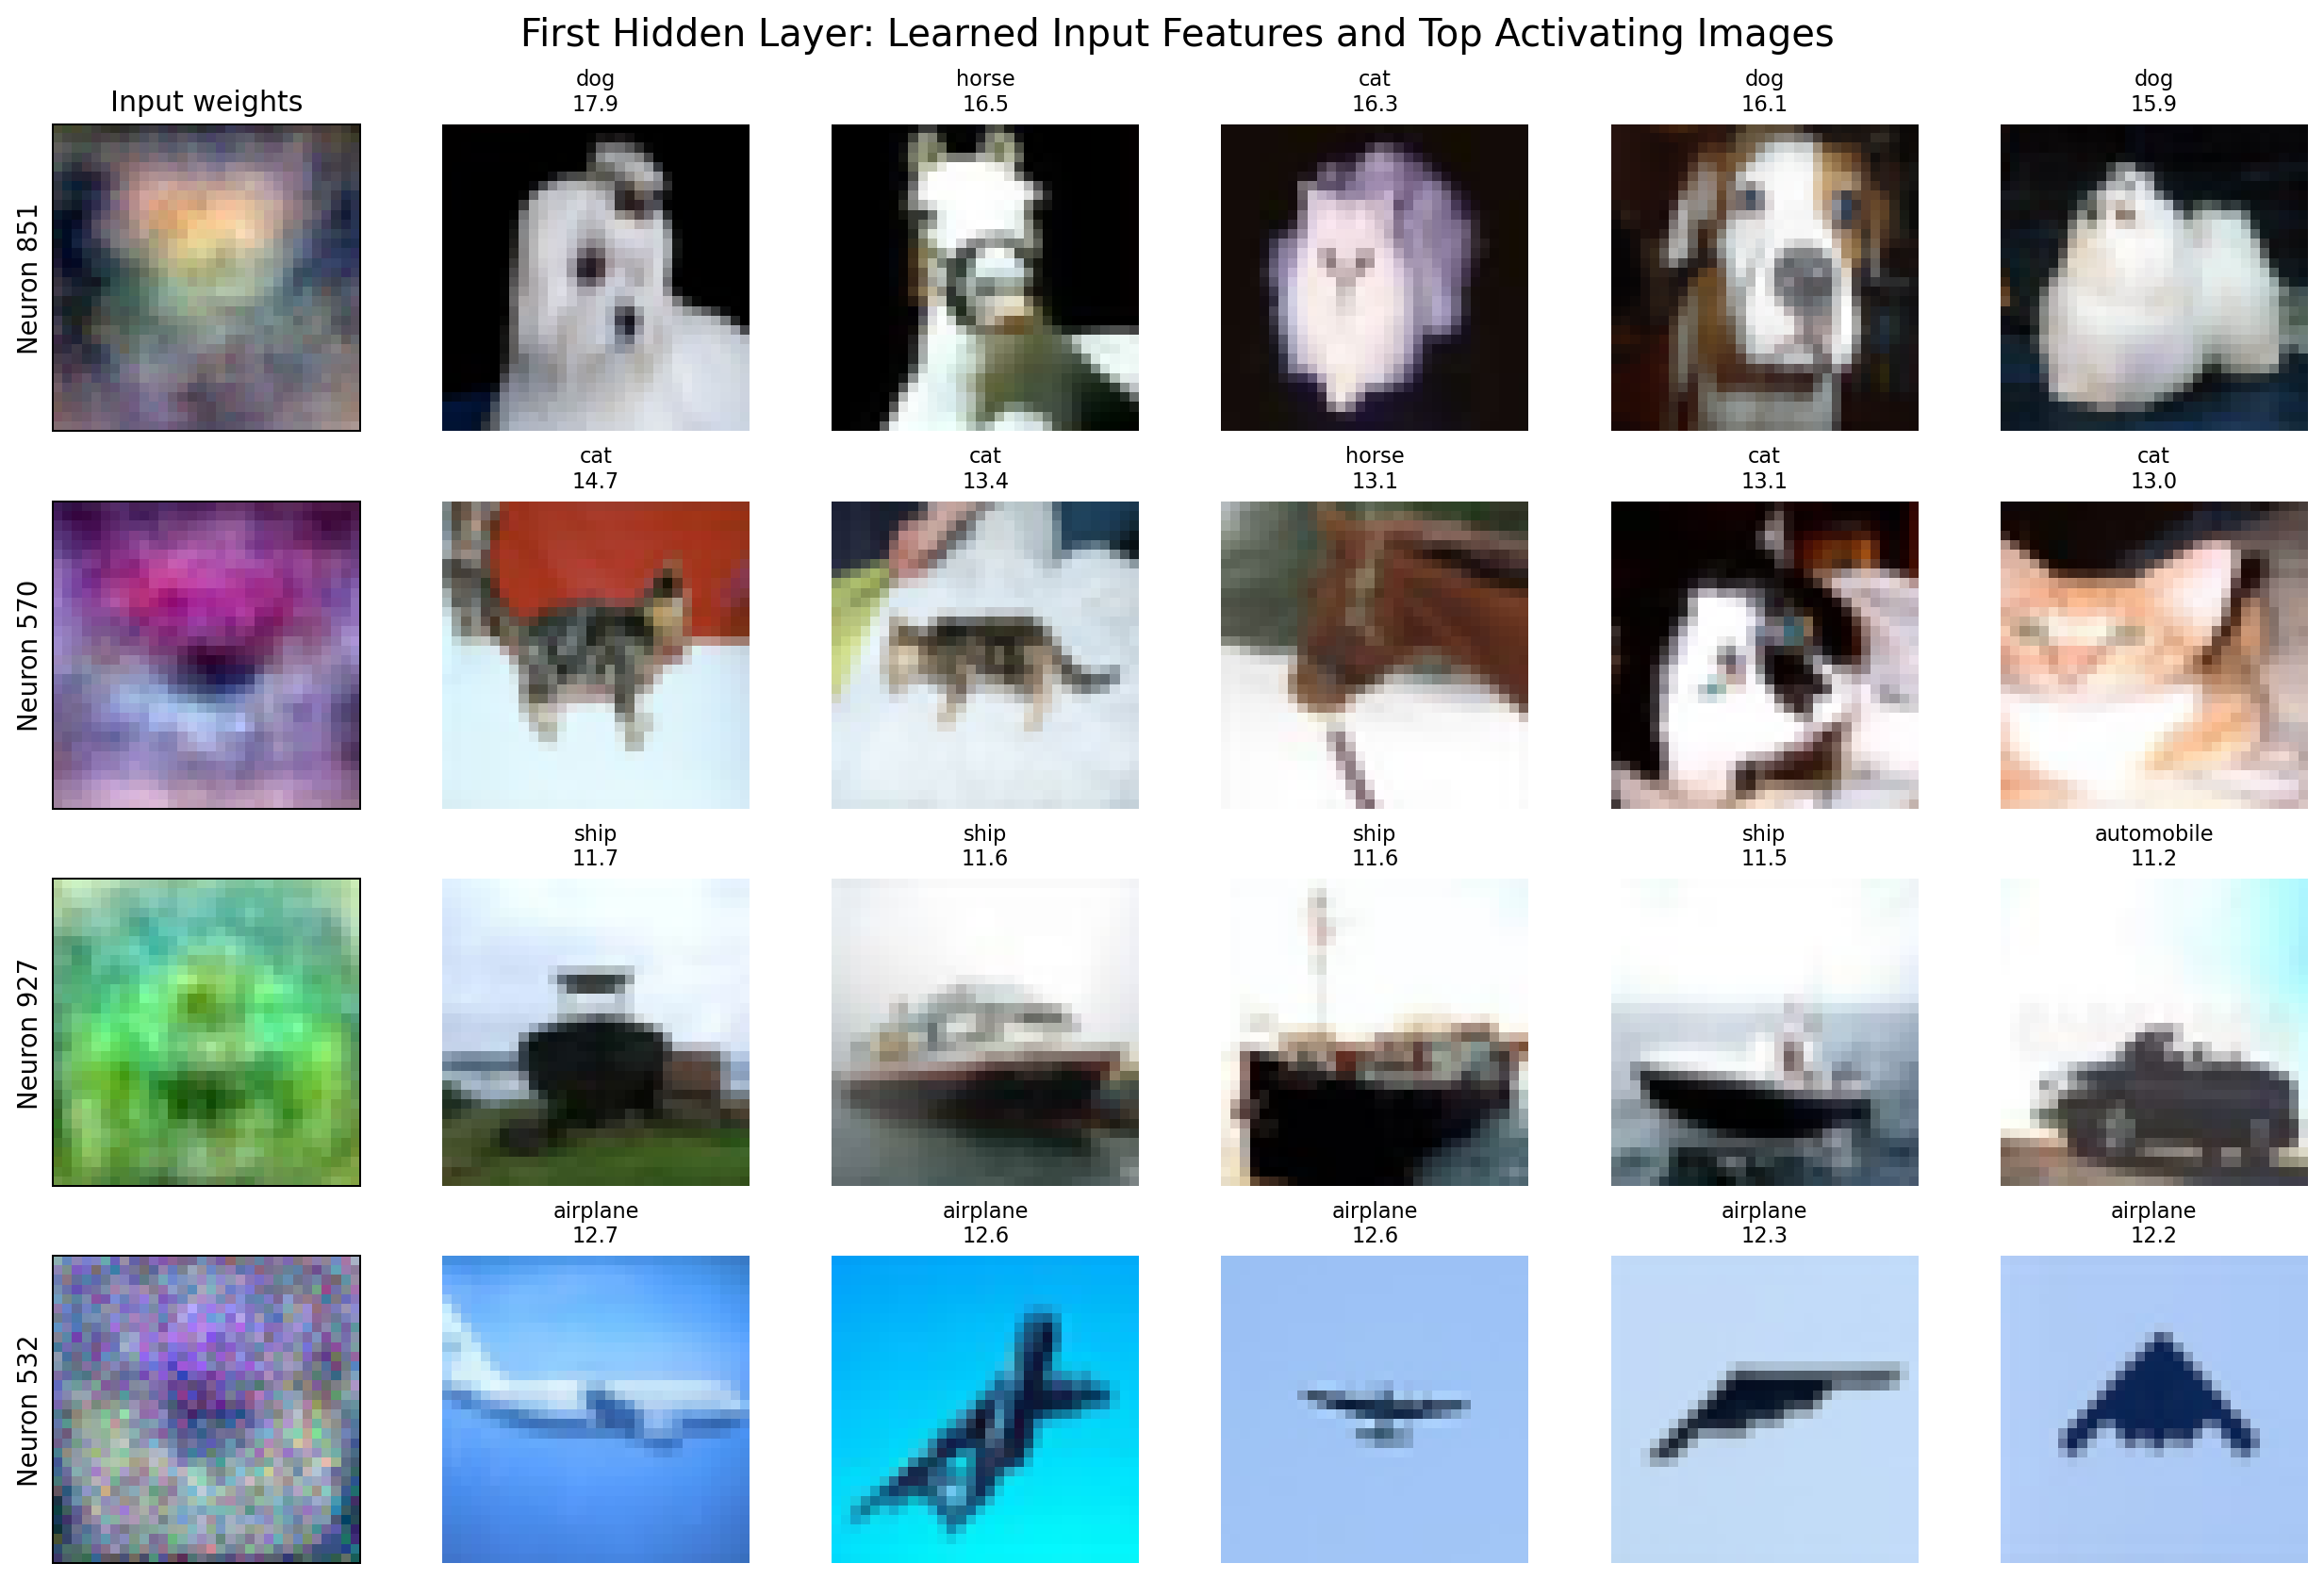

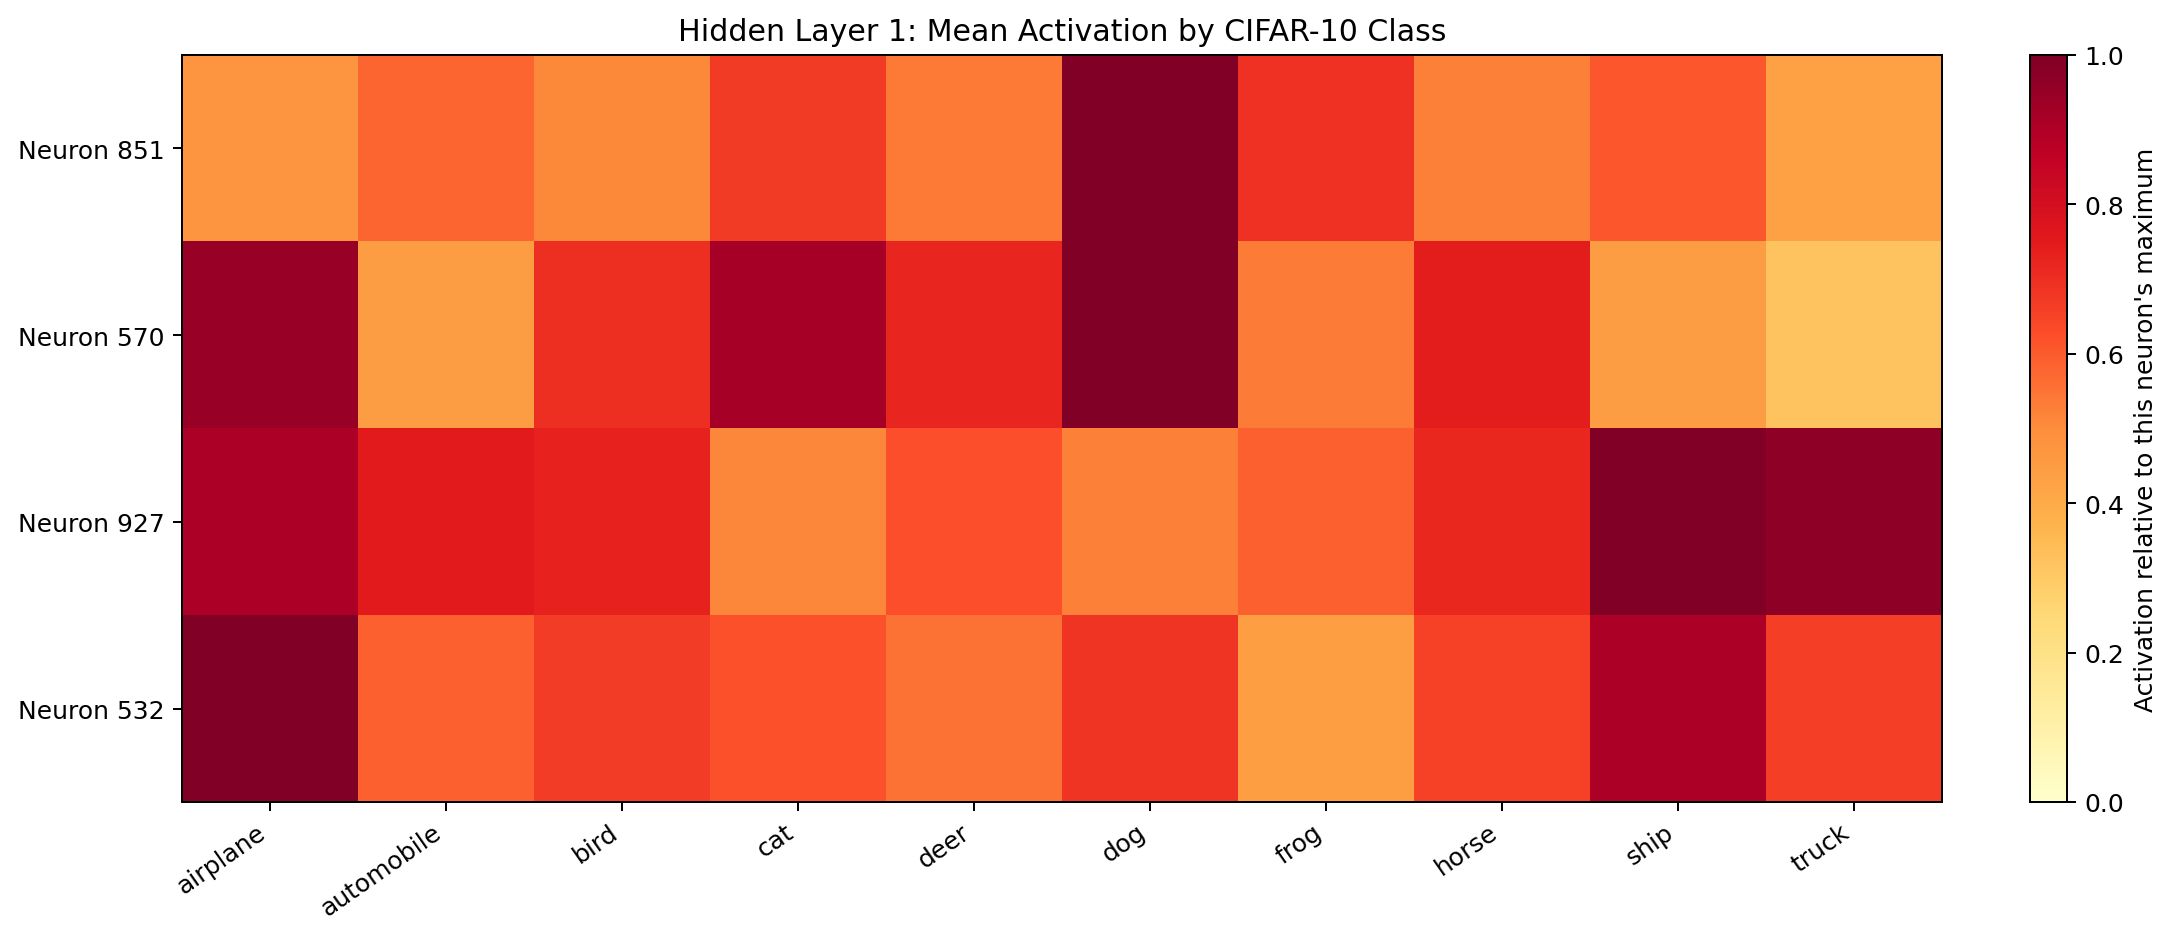

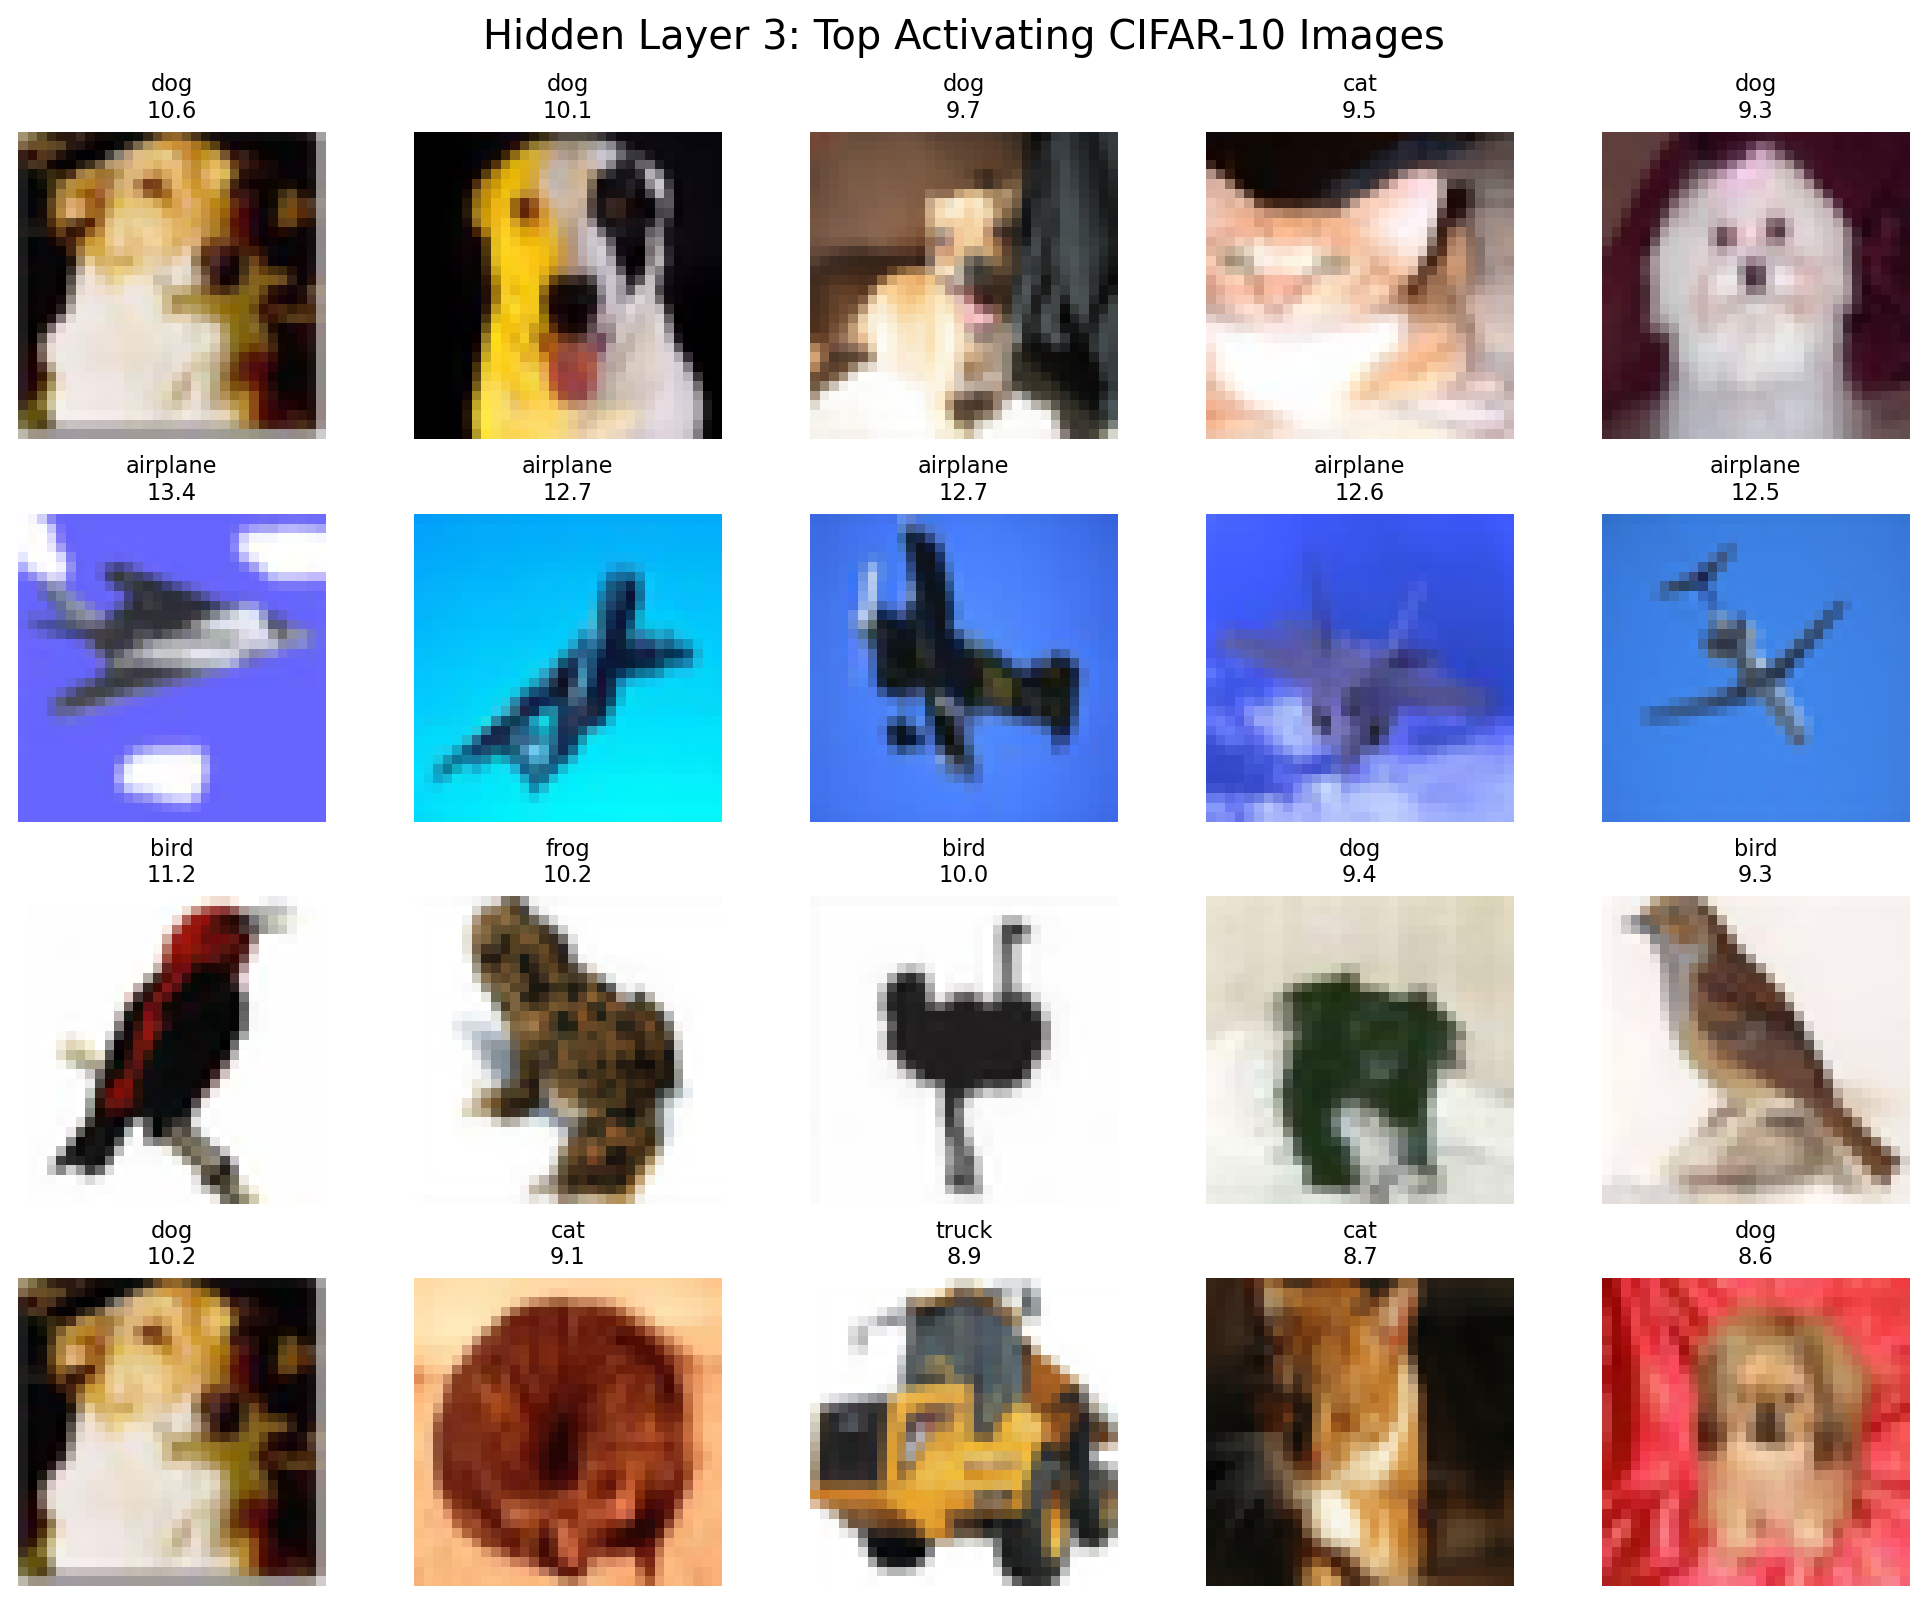

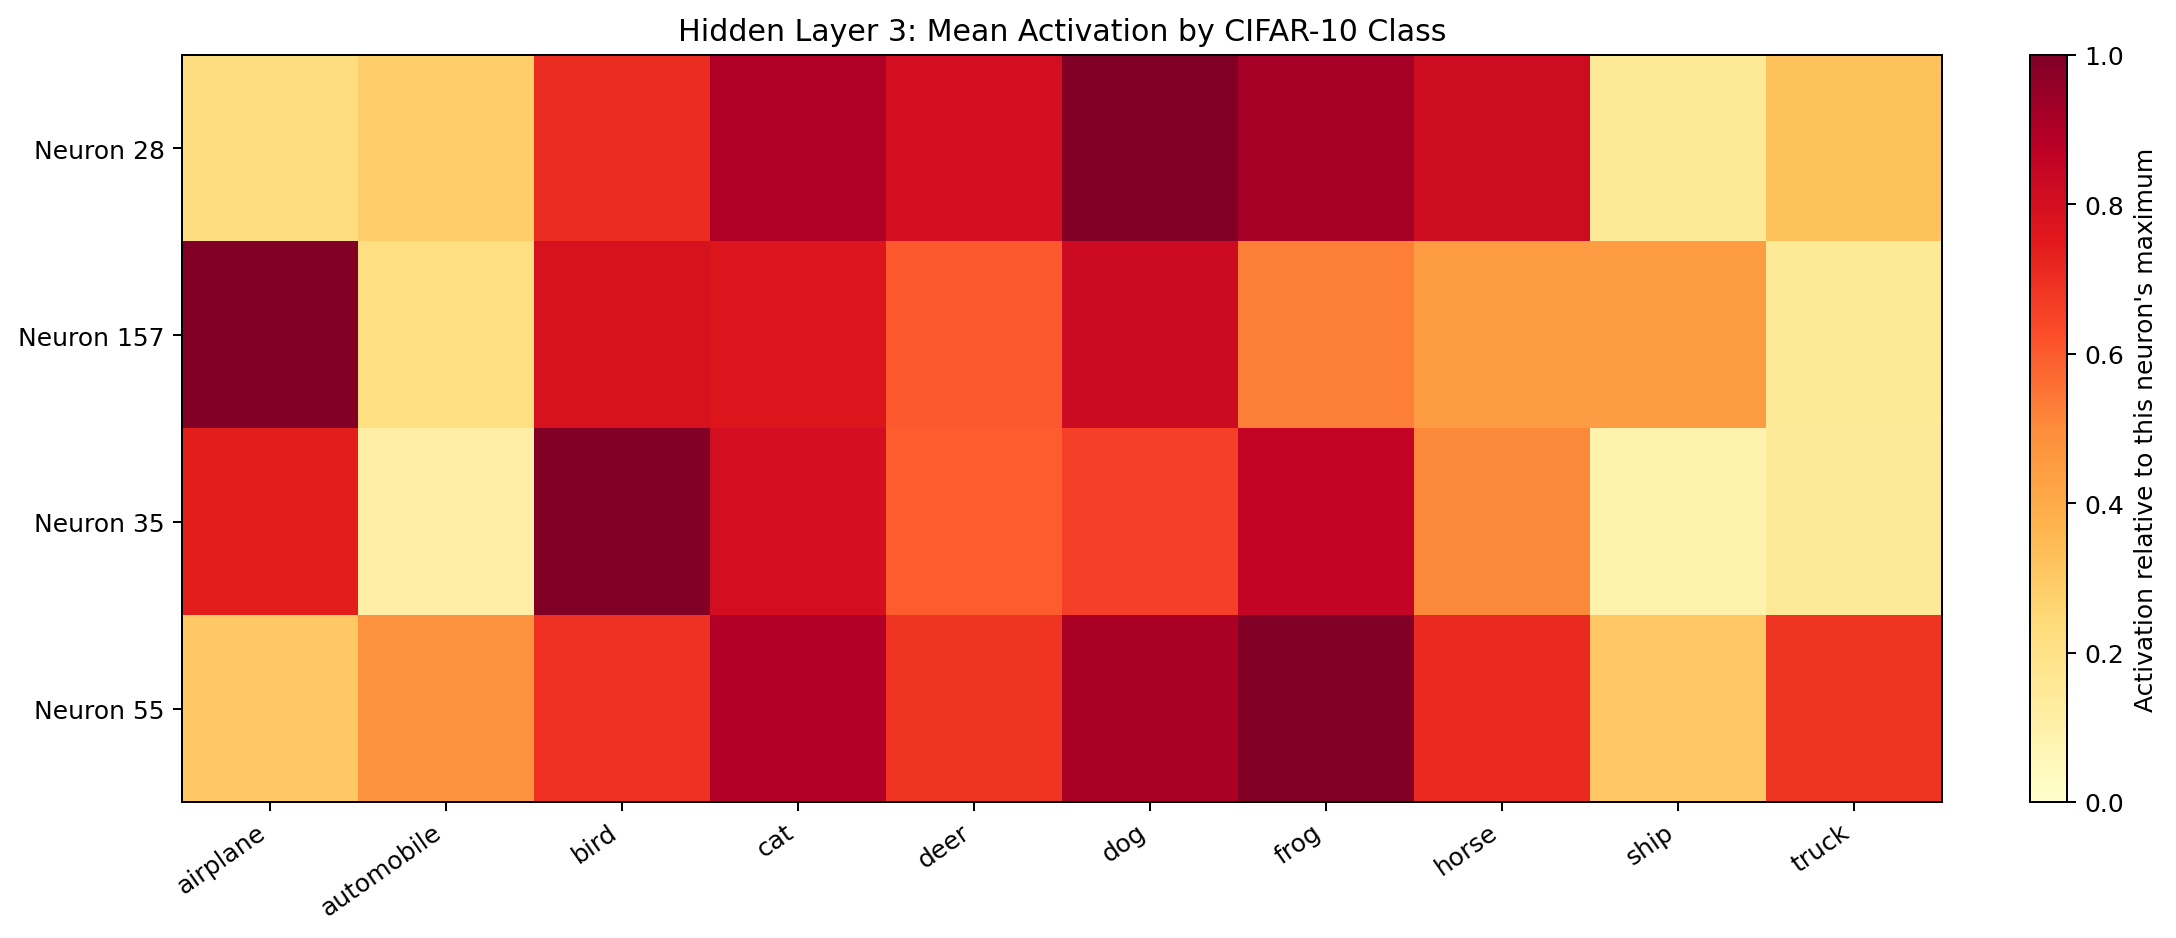

In [23]:
analyze_hidden_layer(feature_model, testloader, layer_id=0)
analyze_hidden_layer(feature_model, testloader, layer_id=2)

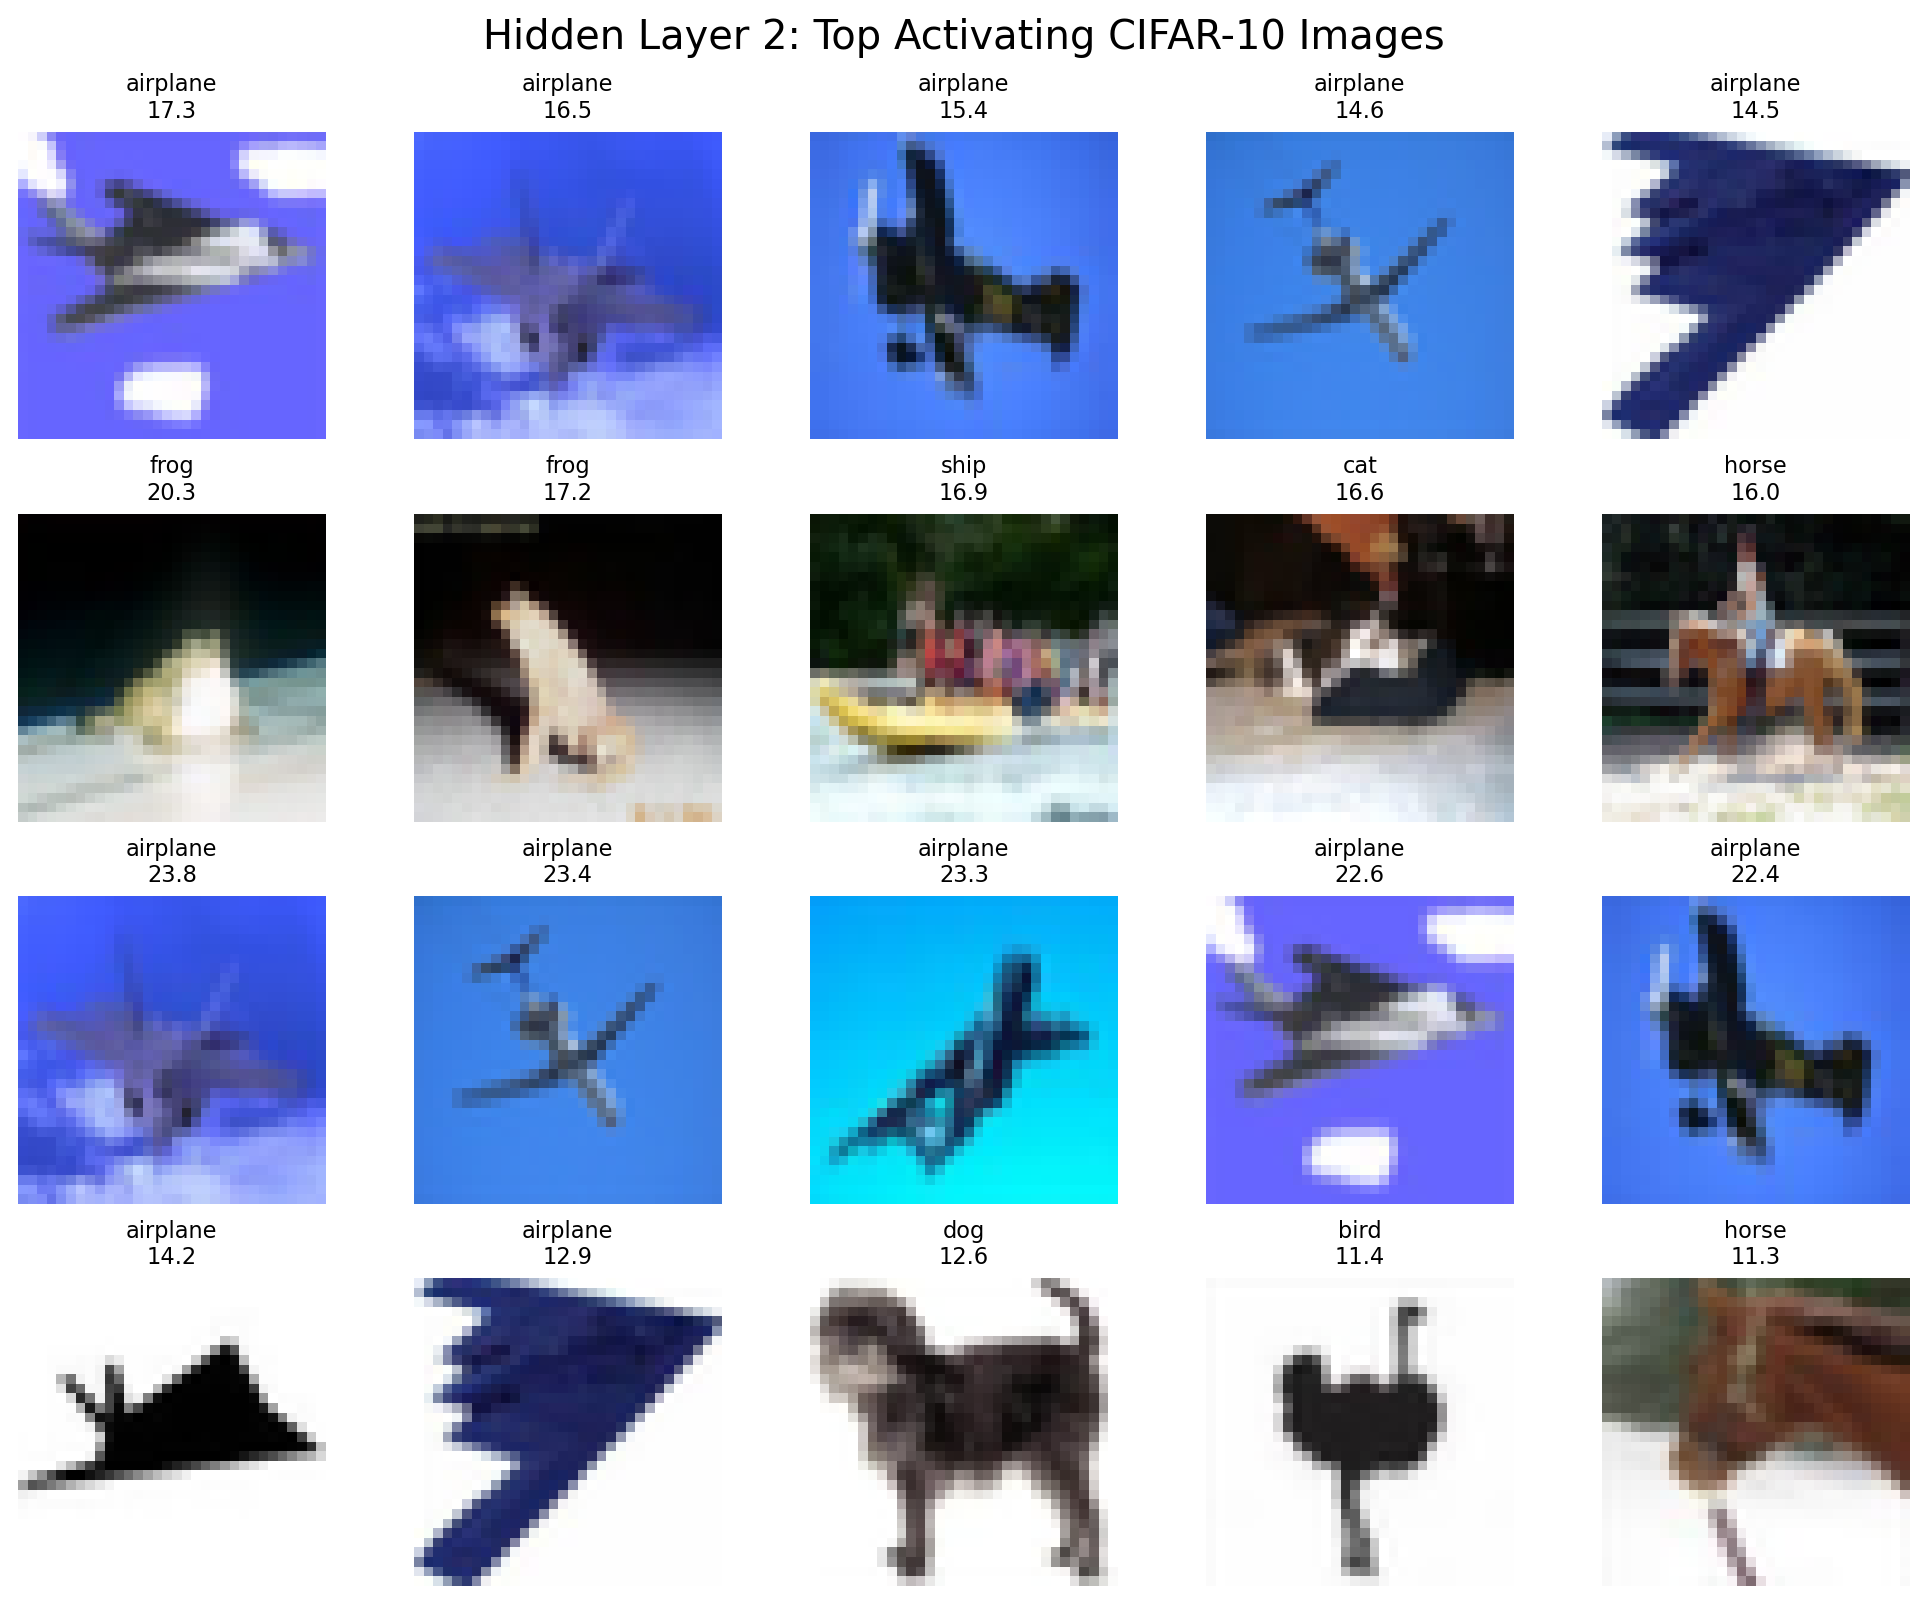

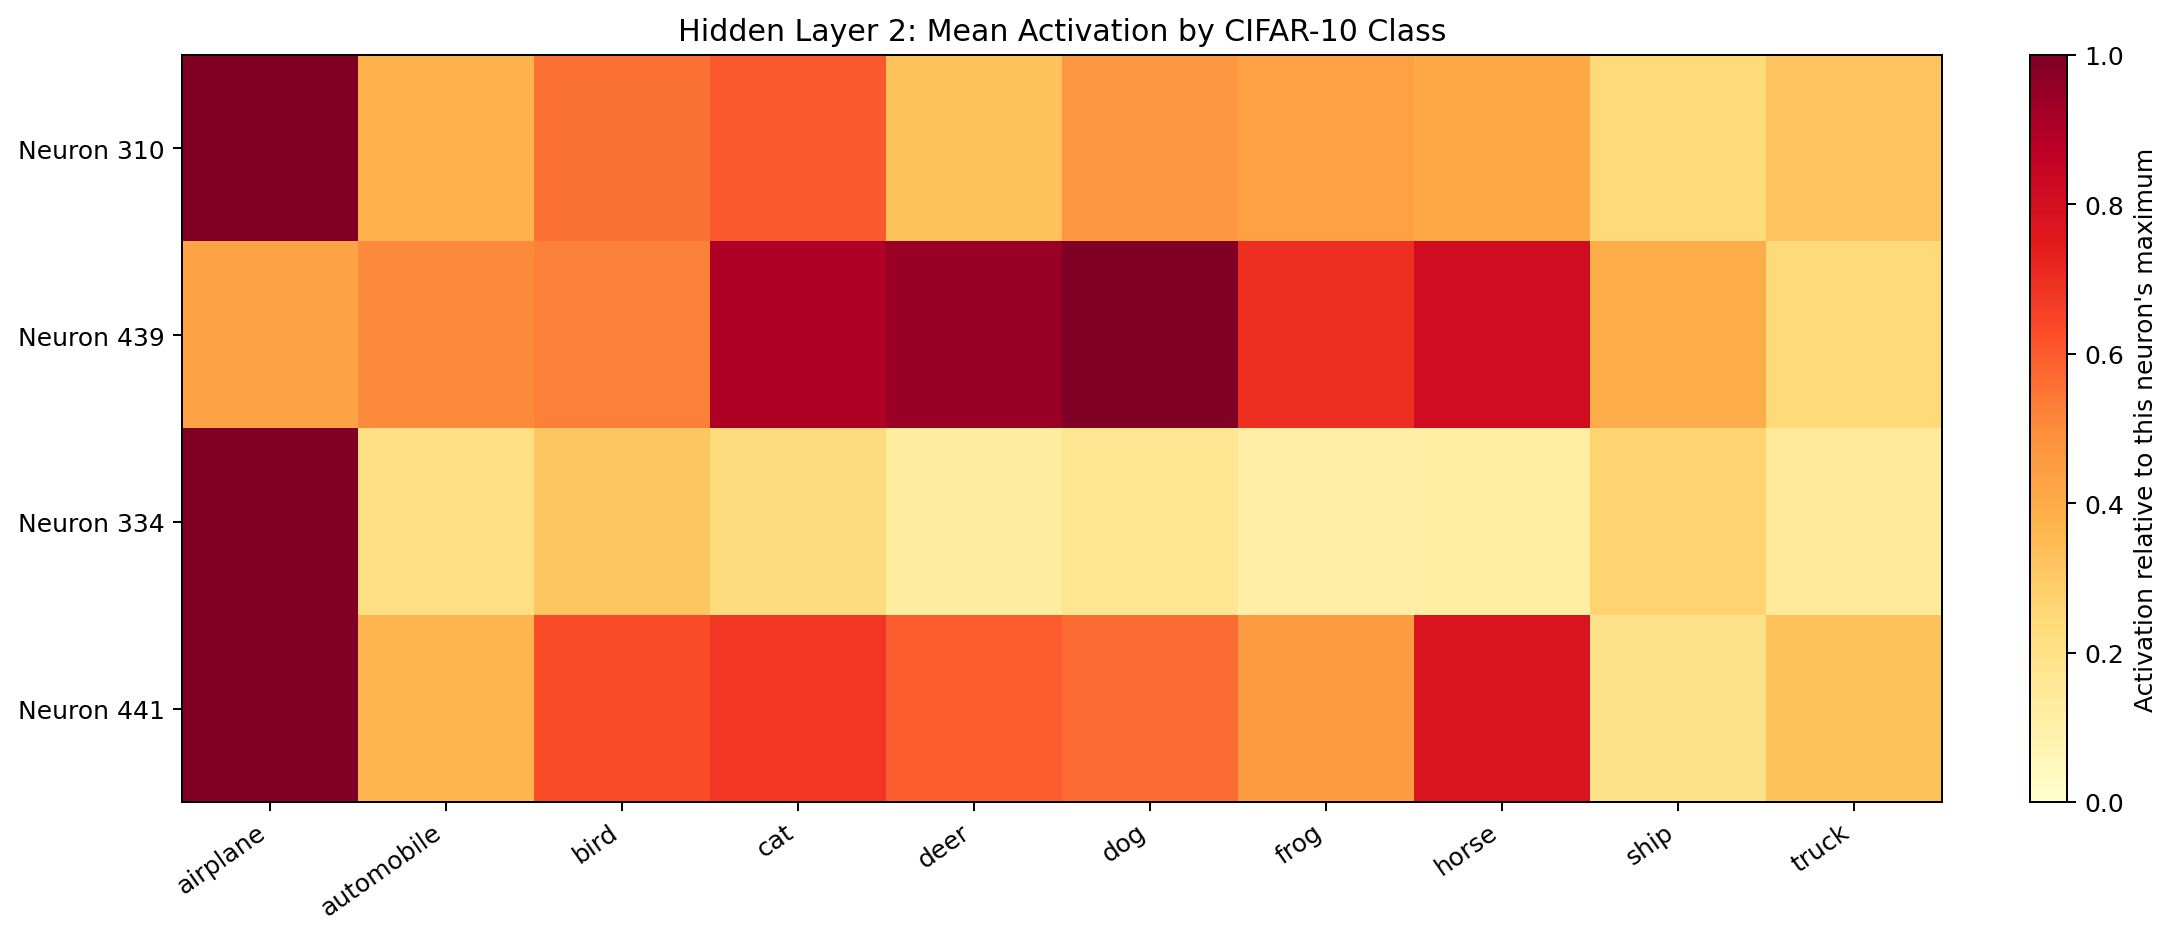

In [24]:
selected_layer_id = 1
analyze_hidden_layer(feature_model, testloader, selected_layer_id)

Layer 3, neuron 47


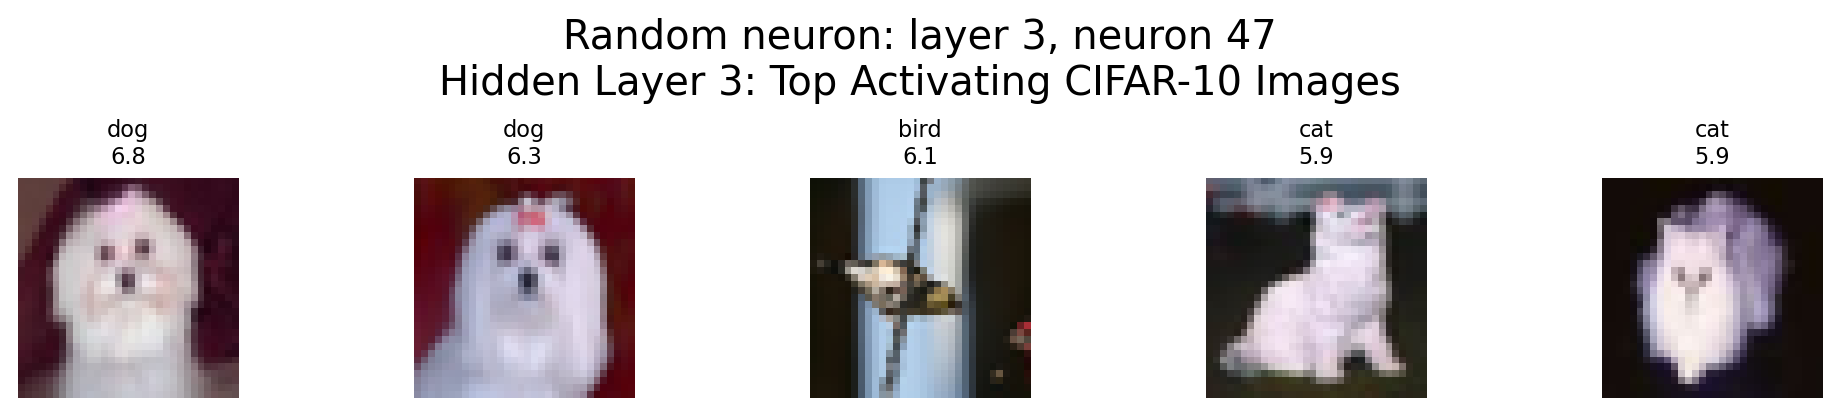

Layer 2, neuron 192


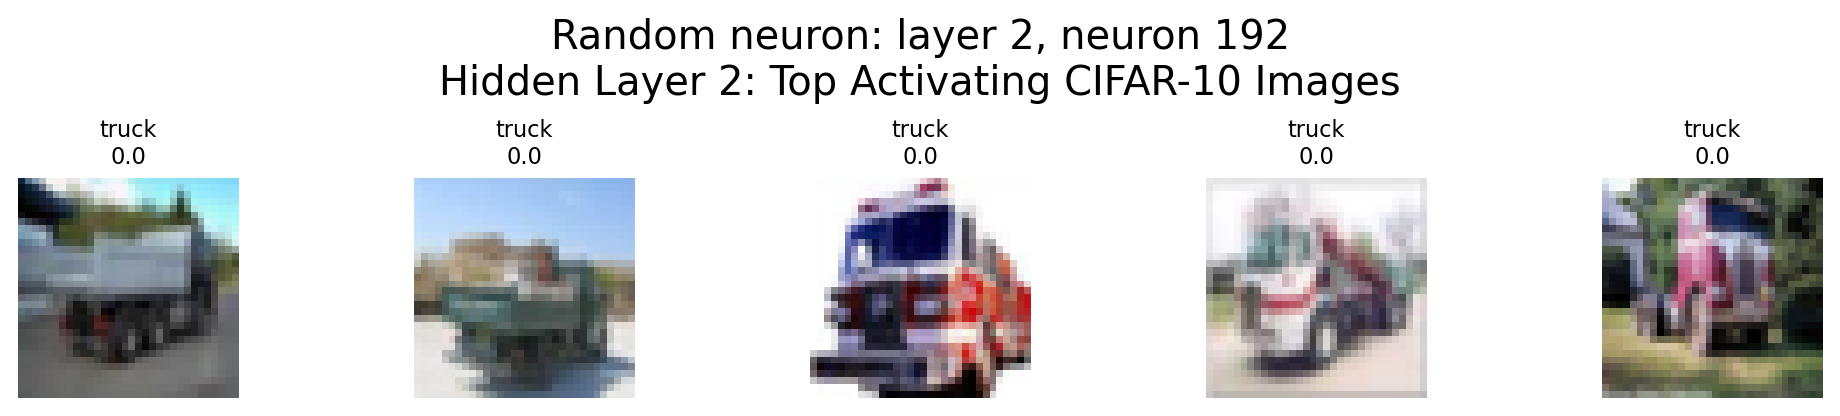

Layer 3, neuron 251


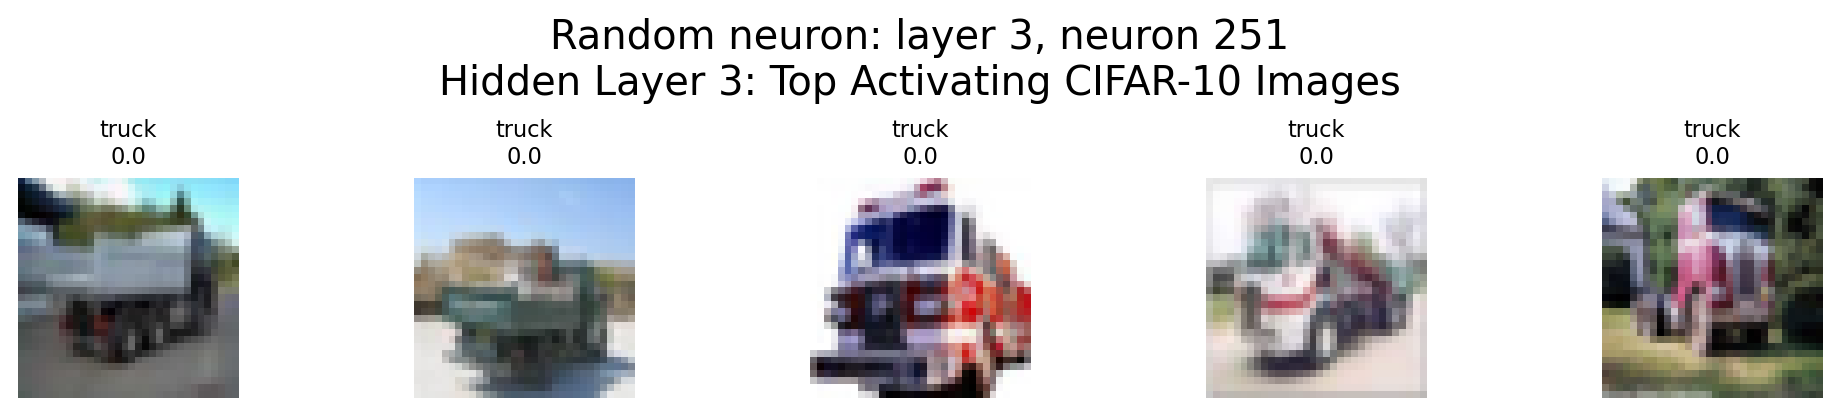

[(2, 47), (1, 192), (2, 251)]

In [25]:
random_neuron_pairs, random_neuron_files = visualize_random_neurons(
    feature_model,
    testloader,
    neuron_pairs=[(2, 47), (1, 192), (2, 251)],
    num_images=5,
    seed=GLOBAL_SEED,
)

random_neuron_pairs


# 03. Effects of Depth and Width

Depth changes how many transformations are composed. Width changes how many neurons are available within a hidden layer. The provided example trains one deep, narrow network. In Task 03, you will update the architecture dictionary and run the same controlled pipeline for several alternatives.

For a fair comparison, keep the CIFAR-10 data, seed, optimizer, learning rate, weight decay, and number of epochs unchanged. Parameter count measures capacity, but it does not directly measure optimization quality or test accuracy.


In [26]:
ARCHITECTURES = {
    "deep_narrow": [256, 256, 256],
}

ARCHITECTURE_LABELS = {
    "deep_narrow": "Deep, narrow\n[256, 256, 256]",
}

ARCHITECTURE_COLORS = {
    "deep_narrow": "#54A24B",
}


## Parameter-Count Helper

`count_parameters` reports model capacity as the total number of trainable scalar parameters.

In [27]:
def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())

## Architecture-Comparison Visualizers

These helpers compare training histories, final accuracy, final loss, and parameter counts across controlled architectures.

In [28]:
def visualize_architecture_comparison(results, output_file):
    figure, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")

    for architecture_name, result in results.items():
        epochs = range(1, len(result["epoch_losses"]) + 1)
        color = ARCHITECTURE_COLORS[architecture_name]
        label = ARCHITECTURE_LABELS[architecture_name].replace("\n", " ")

        axes[0].plot(epochs, result["epoch_losses"], color=color, label=label)
        axes[1].plot(epochs, result["test_accuracies"], color=color, label=label)

    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].grid(alpha=0.25)

    axes[1].set_title("Test Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc="lower right", fontsize=9)

    figure.suptitle("Effects of Neural Network Depth and Width", fontsize=16)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)


def visualize_final_results(results, output_file):
    architecture_names = list(results)
    labels = [ARCHITECTURE_LABELS[name] for name in architecture_names]
    colors = [ARCHITECTURE_COLORS[name] for name in architecture_names]
    final_losses = [results[name]["epoch_losses"][-1] for name in architecture_names]
    final_accuracies = [results[name]["test_accuracies"][-1] for name in architecture_names]
    num_parameters = [results[name]["num_parameters"] for name in architecture_names]

    figure, axes = plt.subplots(1, 3, figsize=(16, 5), layout="constrained")

    axes[0].bar(labels, final_losses, color=colors)
    axes[0].set_title("Final Training Loss")
    axes[0].set_ylabel("Cross-Entropy Loss")

    axes[1].bar(labels, final_accuracies, color=colors)
    axes[1].set_title("Final Test Accuracy")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1)

    axes[2].bar(labels, num_parameters, color=colors)
    axes[2].set_title("Trainable Parameters")
    axes[2].set_ylabel("Parameter count")
    axes[2].set_yscale("log")

    for axis in axes:
        axis.tick_params(axis="x", labelrotation=20)
        axis.grid(axis="y", alpha=0.25)

    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

In [ ]:
def compare_architectures(architectures, num_epochs=20):
    results = {}
    for architecture_name, hidden_layer_sizes in architectures.items():
        set_seed(GLOBAL_SEED)
        model = NeuralNetwork(
            3 * 32 * 32,
            len(CIFAR10_CLASS_NAMES),
            hidden_layer_sizes,
        ).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        print(f"\nTraining {architecture_name}: {hidden_layer_sizes}")
        losses, accuracies = run_gradient_descent_optimizer(
            model, trainloader, testloader, num_epochs,
            nn.CrossEntropyLoss(), optimizer, AccuracyAnalyzer(), device
        )
        results[architecture_name] = {
            "hidden_layer_sizes": hidden_layer_sizes,
            "num_parameters": count_parameters(model),
            "epoch_losses": losses,
            "test_accuracies": accuracies,
        }
    return results

## Run the Controlled Comparison



Training deep_narrow: [256, 256, 256]
Epoch 01/2: loss=2.1058, test_accuracy=0.2197
Epoch 02/2: loss=1.9282, test_accuracy=0.3219


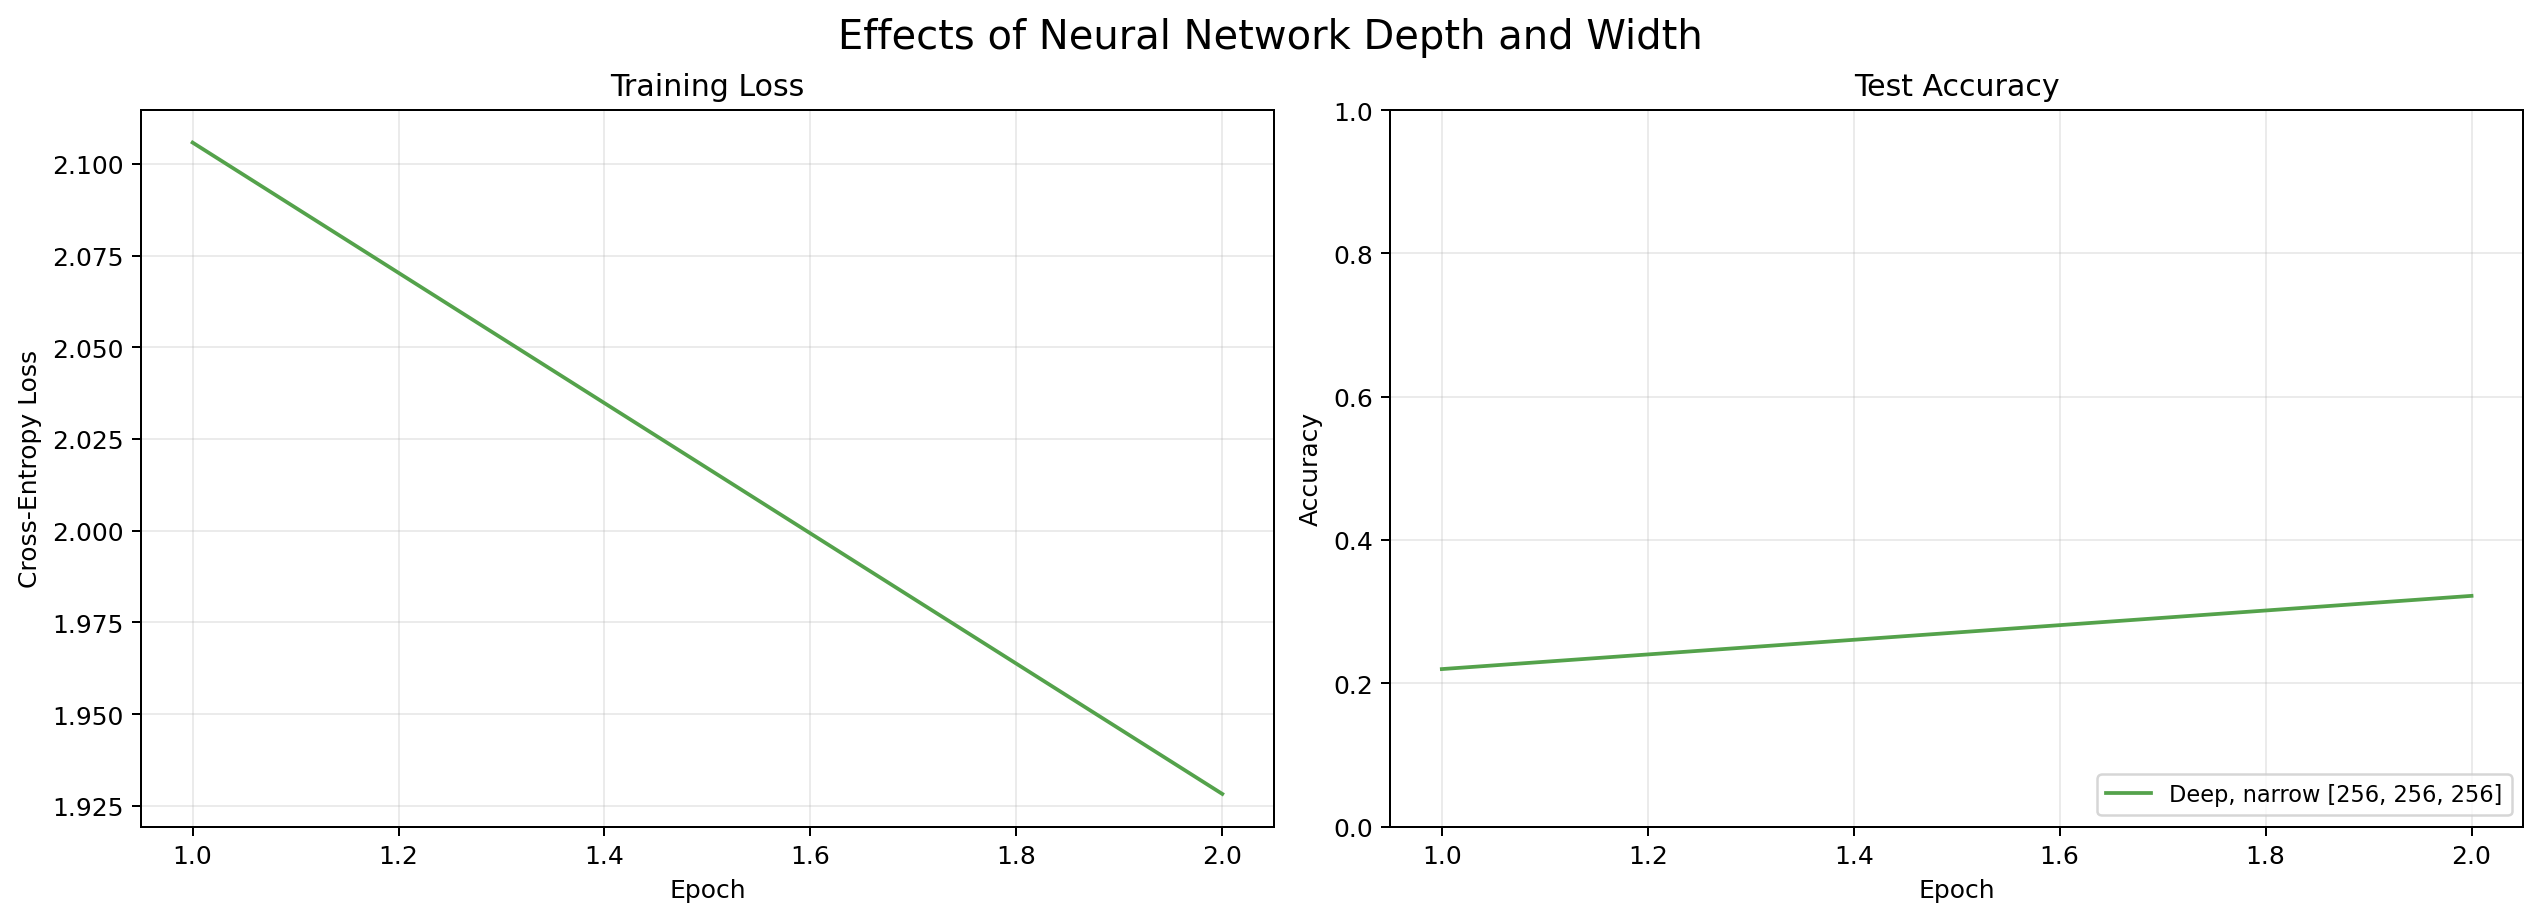

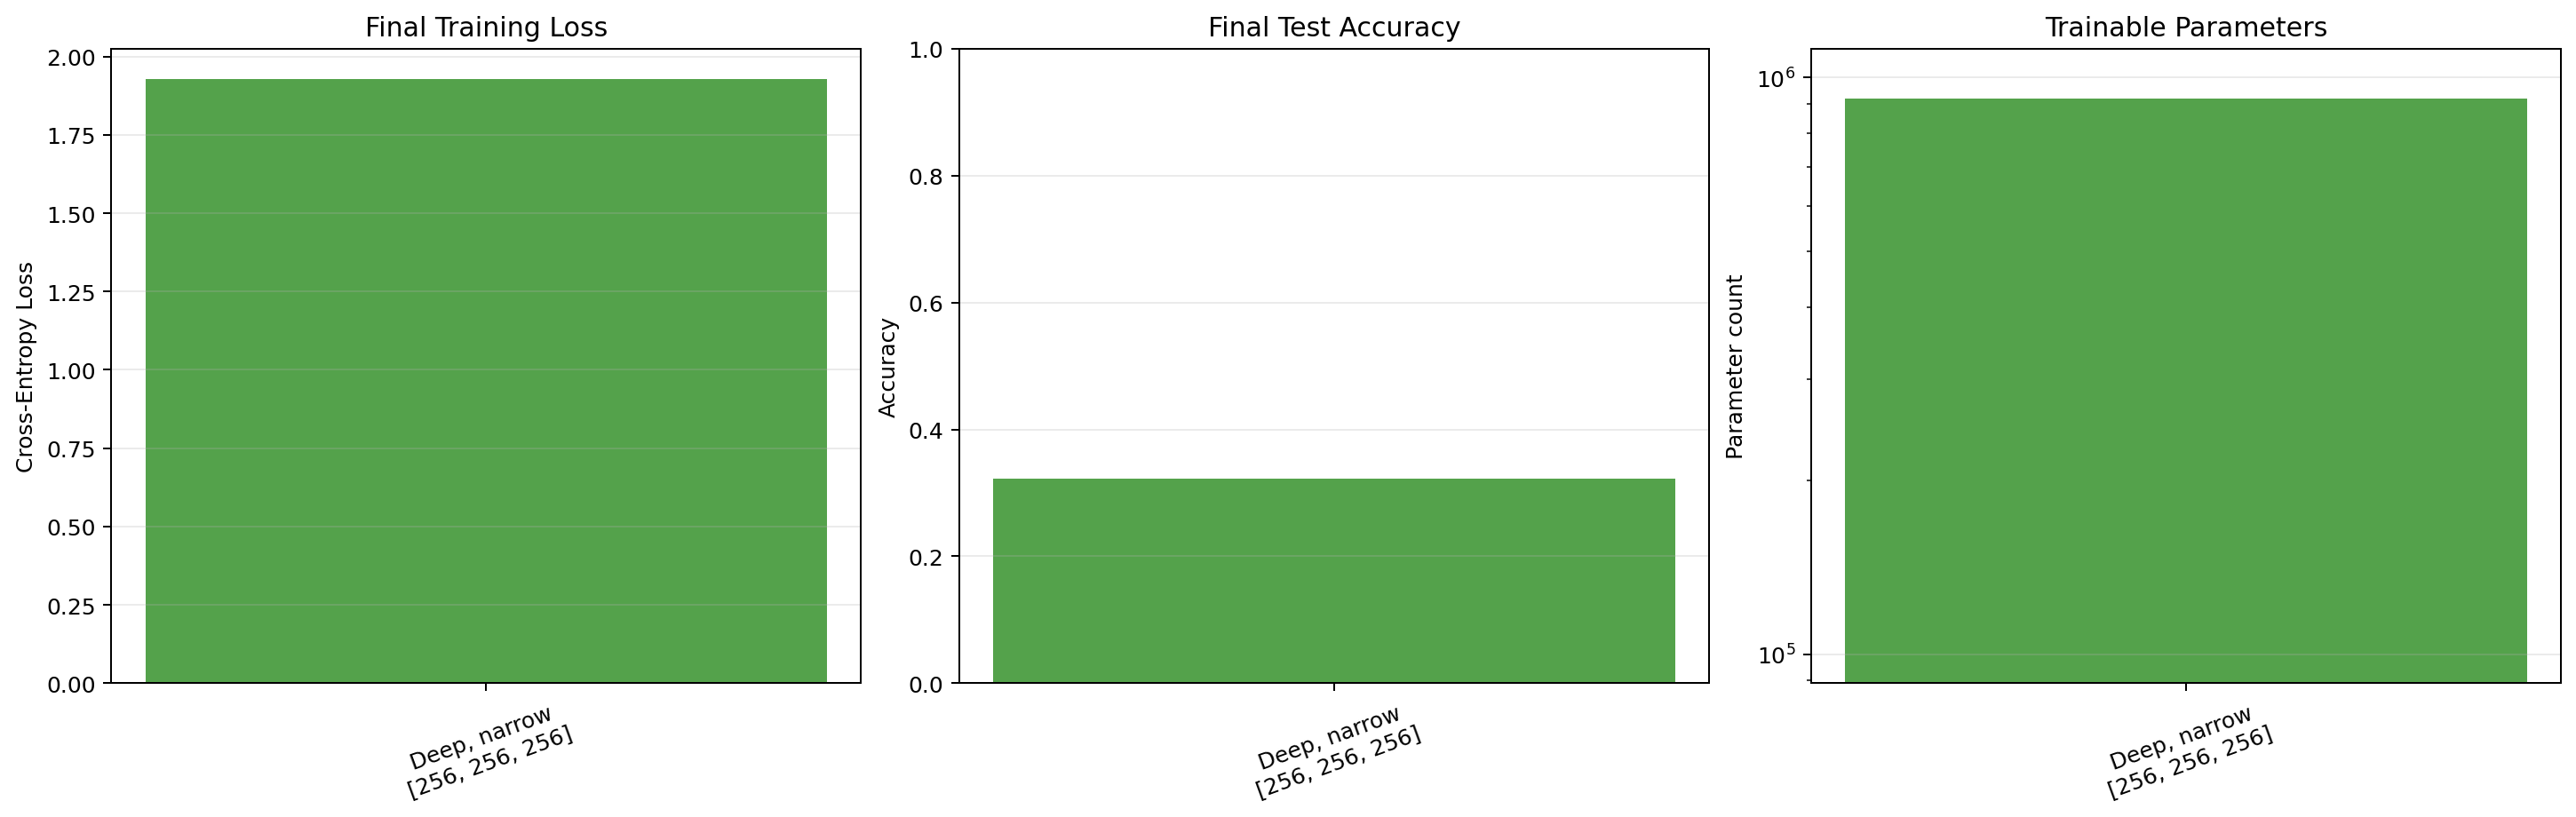

In [32]:
architecture_results = compare_architectures(ARCHITECTURES)

architecture_output_dir = Path(OUTPUT_DIR) / "03_depth_and_width"
architecture_output_dir.mkdir(parents=True, exist_ok=True)
visualize_architecture_comparison(
    architecture_results,
    architecture_output_dir / "01_deep_narrow_training.png",
)
visualize_final_results(
    architecture_results,
    architecture_output_dir / "02_deep_narrow_results.png",
)

display(Image(filename=architecture_output_dir / "01_deep_narrow_training.png"))
display(Image(filename=architecture_output_dir / "02_deep_narrow_results.png"))


In [33]:
ARCHITECTURES = {
    "shallow_narrow": [256],
    "shallow_wide": [1024],
    "deep_narrow": [256, 256, 256],
    "deep_wide": [1024, 1024, 1024],
    "diamond": [256, 1024, 256]
}

ARCHITECTURE_LABELS = {
    "shallow_narrow": "Shallow, narrow\n[256]",
    "shallow_wide": "Shallow, wide\n[1024]",
    "deep_narrow": "Deep, narrow\n[256, 256, 256]",
    "deep_wide": "Deep, wide\n[1024, 1024, 1024]",
    "diamond": "Diamond\n[256, 1024, 256]"
}

ARCHITECTURE_COLORS = {
    "shallow_narrow": "#3498DB",
    "shallow_wide": "#E67E22",
    "deep_narrow": "#54A24B",
    "deep_wide": "#C0392B",
    "diamond": "#8E44AD"
}



Training shallow_narrow: [256]
Epoch 01/2: loss=1.9466, test_accuracy=0.3545
Epoch 02/2: loss=1.7540, test_accuracy=0.4001

Training shallow_wide: [1024]
Epoch 01/2: loss=1.9279, test_accuracy=0.3773
Epoch 02/2: loss=1.7341, test_accuracy=0.3992

Training deep_narrow: [256, 256, 256]
Epoch 01/2: loss=2.1082, test_accuracy=0.2530
Epoch 02/2: loss=1.9390, test_accuracy=0.3065

Training deep_wide: [1024, 1024, 1024]
Epoch 01/2: loss=2.0293, test_accuracy=0.3117
Epoch 02/2: loss=1.8038, test_accuracy=0.3849

Training diamond: [256, 1024, 256]
Epoch 01/2: loss=2.0599, test_accuracy=0.2727
Epoch 02/2: loss=1.8402, test_accuracy=0.3689


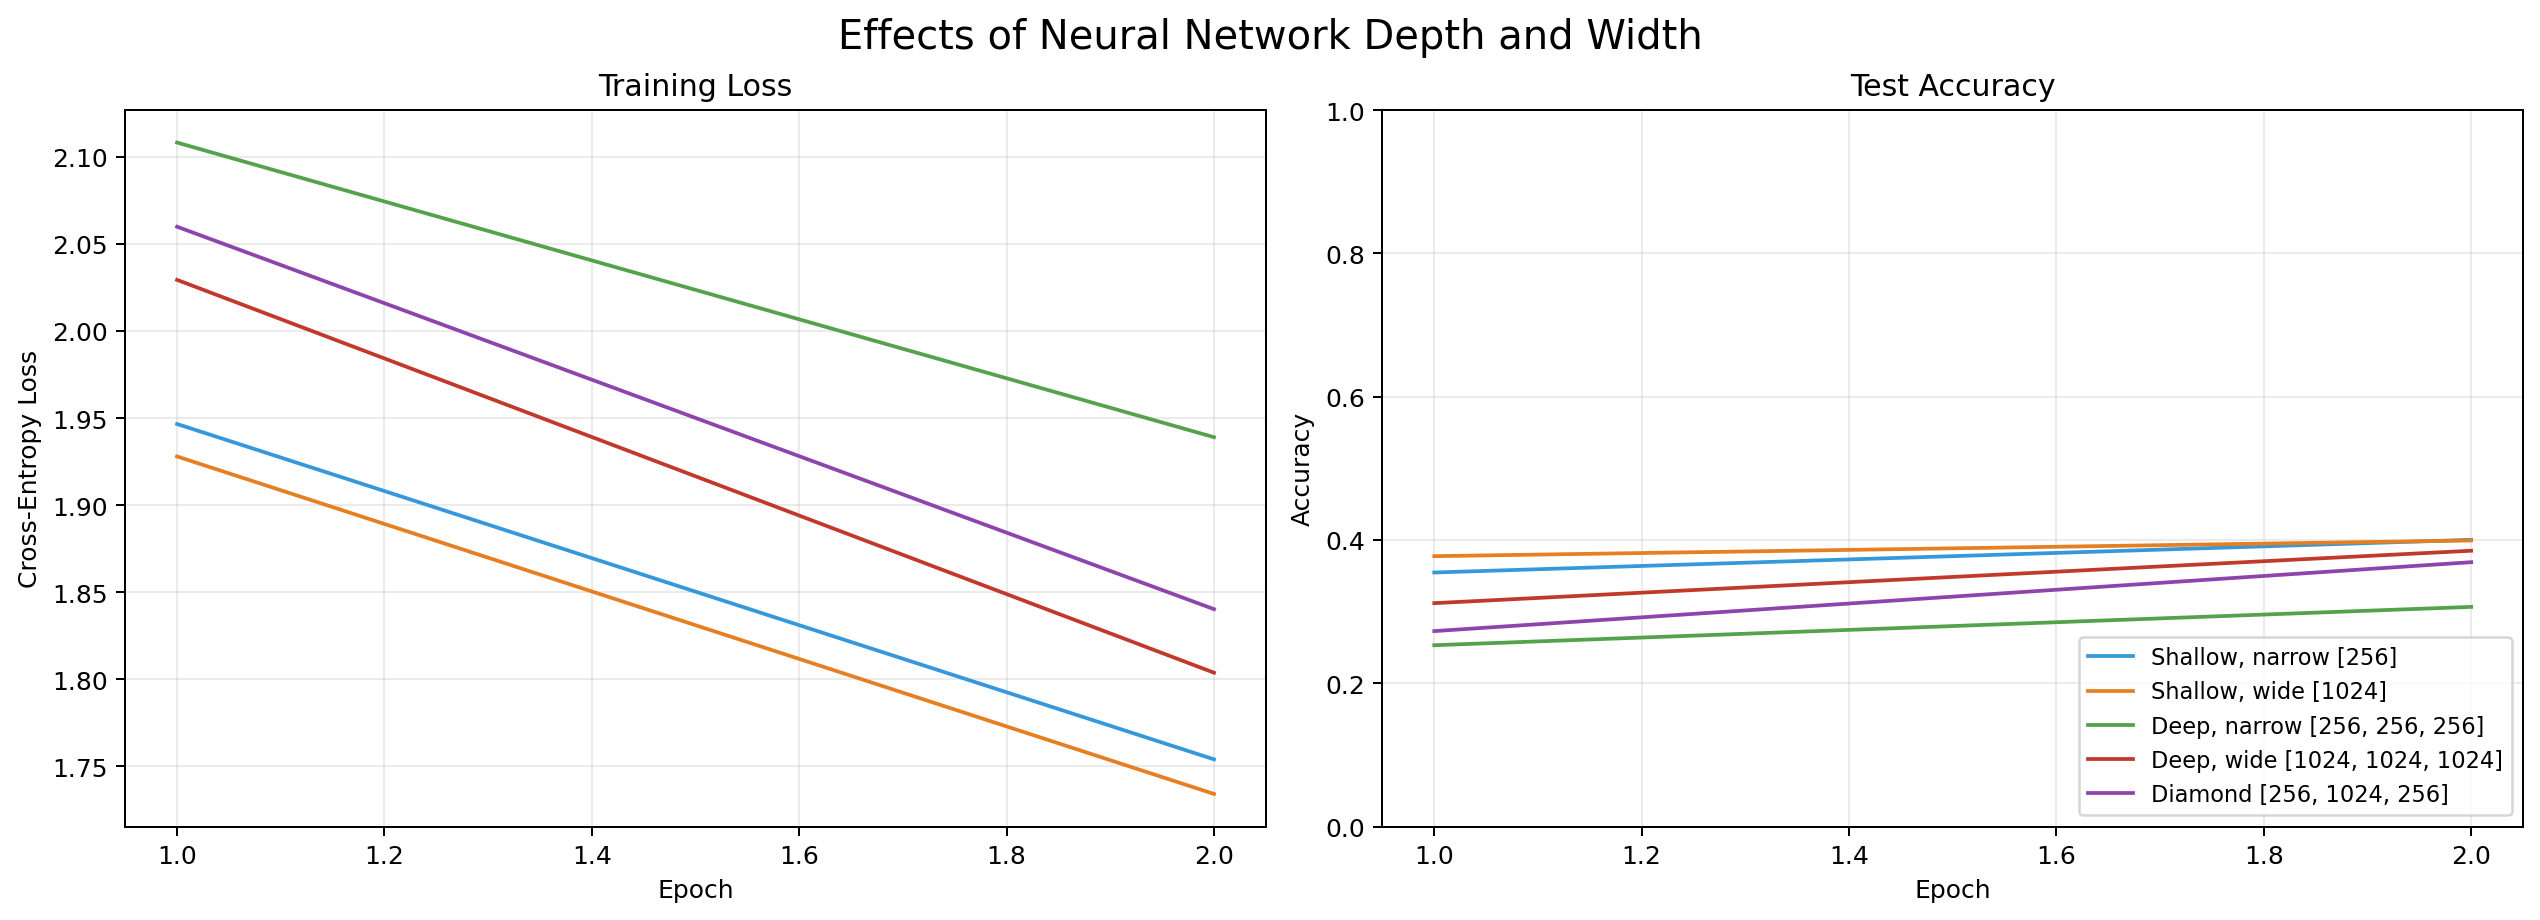

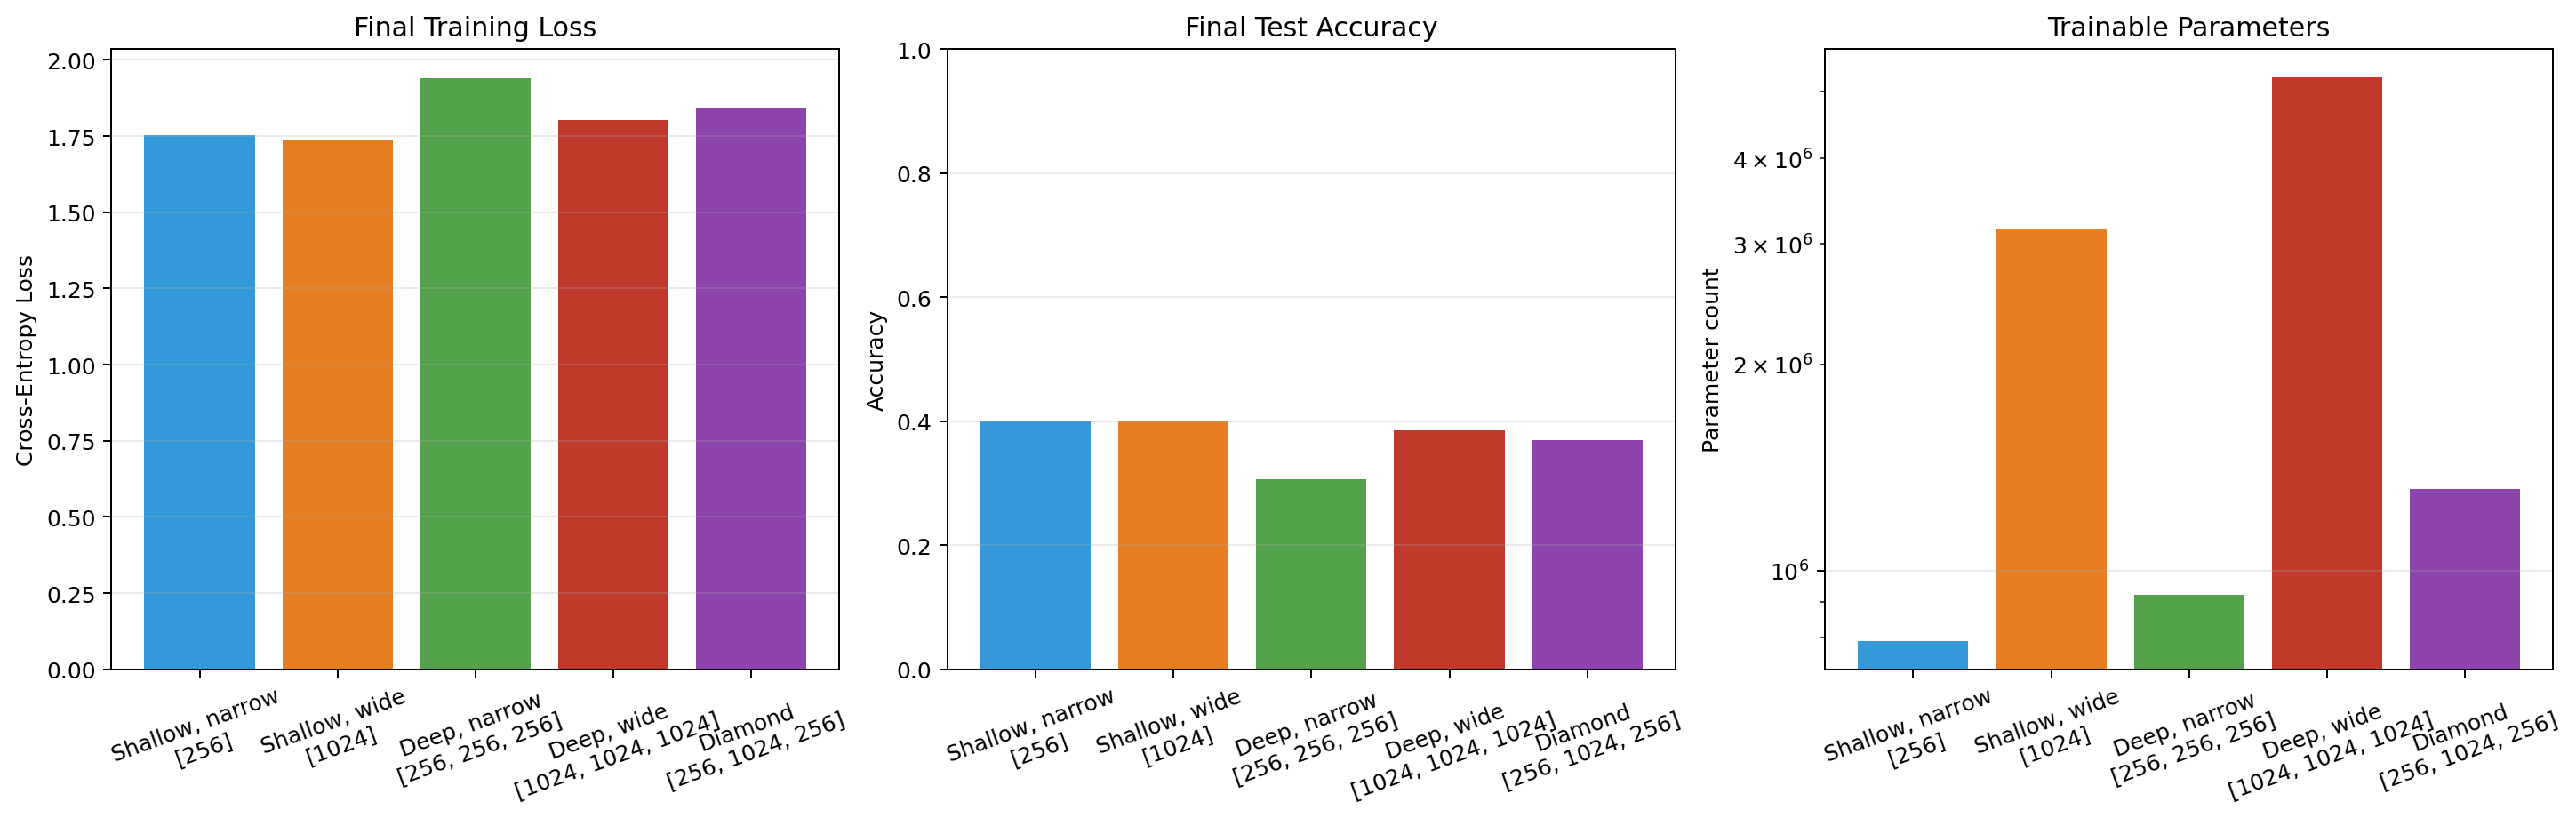

In [34]:
architecture_results = compare_architectures(ARCHITECTURES)
visualize_architecture_comparison(
    architecture_results,
    architecture_output_dir / "03_student_training_comparison.png",
)
visualize_final_results(
    architecture_results,
    architecture_output_dir / "04_student_final_results.png",
)

display(Image(filename=architecture_output_dir / "03_student_training_comparison.png"))
display(Image(filename=architecture_output_dir / "04_student_final_results.png"))


The shallow narrow network has the fewest parameters, so it is the easiest to optimize but has limited capacity. The shallow wide model increases capacity mostly by adding more parallel hidden units, and it usually trains more smoothly than adding many extra layers. The deep narrow model adds transformations but not much width, so it can represent more compositions while also making optimization harder.

The deep wide network has by far the most parameters. It can drive training loss down strongly, but that does not automatically mean the best test accuracy because CIFAR-10 is small relative to the model size and the network is fully connected. The funnel model is a compromise: it starts wide enough to capture many input patterns and then compresses them. I expected shallow wide or funnel to be the most stable, while deep wide might overfit or show less stable improvement despite its larger capacity.


# 04. Backpropagation Through a Small Computation Graph

The graph below contains two ReLU branches. Each input-to-hidden weight receives a gradient scaled by its input and by the downstream weight on its branch. ReLU can stop an entire branch's gradient when its pre-activation is negative.

The graph visualizer is generic: it reads the actual PyTorch autograd graph. Adding a skip connection changes the generated diagram without changing the visualizer.


In [35]:
PARAMETER_ORDER = ["w1", "w2", "w3", "w4", "v1", "v2", "b"]
PARAMETER_COLORS = {
    "w1": "#2A9D8F", "w2": "#2A9D8F",
    "w3": "#E9C46A", "w4": "#E9C46A",
    "v1": "#457B9D", "v2": "#F4A261", "b": "#8D99AE",
}

## Generic Autograd Graph Visualizer

`visualize_autograd_graph` uses the actual PyTorch autograd graph and annotates named tensors with forward values and gradients.

In [36]:
def summarize_tensor(name, tensor):
    detached = tensor.detach()

    if detached.numel() == 1:
        value_summary = f"value={detached.cpu().item():+.3f}"
    else:
        value_summary = f"value_norm={detached.norm().cpu().item():.3f}"

    if tensor.grad is None:
        gradient_summary = "grad=None"
    elif tensor.grad.numel() == 1:
        gradient_summary = f"grad={tensor.grad.detach().cpu().item():+.3f}"
    else:
        gradient_summary = f"grad_norm={tensor.grad.detach().norm().cpu().item():.3f}"

    return f"{name}\n{value_summary}\n{gradient_summary}"


def visualize_autograd_graph(outputs, named_tensors, output_file):
    output_file = Path(output_file)
    output_file.parent.mkdir(parents=True, exist_ok=True)

    if torch.is_tensor(outputs):
        outputs = (outputs,)

    annotated_tensors = {
        summarize_tensor(name, tensor): tensor
        for name, tensor in named_tensors.items()
    }
    graph = make_dot(
        tuple(outputs),
        params=annotated_tensors,
        show_attrs=False,
        show_saved=False,
    )
    graph.graph_attr.update(
        rankdir="LR",
        bgcolor="white",
        pad="0.2",
        nodesep="0.35",
        ranksep="0.55",
        dpi="180",
    )
    graph.node_attr.update(fontname="monospace", fontsize="10")
    graph.edge_attr.update(color="#5C677D", arrowsize="0.8")

    graph.render(
        filename=output_file.stem,
        directory=output_file.parent,
        format=output_file.suffix.lstrip("."),
        cleanup=True,
    )

## Small Computation Graph

`make_parameters` creates scalar trainable weights. `run_computation_graph` builds two ReLU branches, retains intermediate gradients, and runs backpropagation.

In [37]:
def make_parameters(device):
    return {
        "w1": torch.tensor(0.60, device=device, requires_grad=True),
        "w2": torch.tensor(-0.40, device=device, requires_grad=True),
        "w3": torch.tensor(0.25, device=device, requires_grad=True),
        "w4": torch.tensor(0.40, device=device, requires_grad=True),
        "v1": torch.tensor(1.50, device=device, requires_grad=True),
        "v2": torch.tensor(0.25, device=device, requires_grad=True),
        "b": torch.tensor(0.00, device=device, requires_grad=True),
    }


def run_computation_graph(parameters, device, target=1.0, skip_weight=None):
    x1 = torch.tensor(2.0, device=device, requires_grad=True)
    x2 = torch.tensor(0.5, device=device, requires_grad=True)
    target = torch.tensor(target, device=device, requires_grad=True)

    z1 = parameters["w1"] * x1 + parameters["w2"] * x2
    z2 = parameters["w3"] * x1 + parameters["w4"] * x2
    h1 = torch.relu(z1)
    h2 = torch.relu(z2)
    prediction = parameters["v1"] * h1 + parameters["v2"] * h2 + parameters["b"]
    if skip_weight is not None:
        prediction = prediction + skip_weight * x1
    loss = 0.5 * (prediction - target) ** 2

    for tensor in [z1, z2, h1, h2, prediction, loss]:
        tensor.retain_grad()

    loss.backward(retain_graph=True)

    return {
        "x1": x1,
        "x2": x2,
        "z1": z1,
        "z2": z2,
        "h1": h1,
        "h2": h2,
        "prediction": prediction,
        "target": target,
        "loss": loss,
    }


def scalar(tensor):
    return tensor.detach().cpu().item()


def gradient(tensor):
    if tensor.grad is None:
        return None
    return tensor.grad.detach().cpu().item()

## Backpropagation Visualizers

These helpers compare gradient magnitudes, ReLU gating, and the parameter updates produced by one gradient-descent step.

### `visualize_gradient_magnitudes`

In [38]:
def visualize_gradient_magnitudes(nodes, parameters, output_file):
    gradients = [abs(gradient(parameters[name])) for name in PARAMETER_ORDER]
    colors = [PARAMETER_COLORS[name] for name in PARAMETER_ORDER]

    figure, axes = plt.subplots(1, 2, figsize=(15, 5), layout="constrained")
    bars = axes[0].bar(PARAMETER_ORDER, gradients, color=colors)
    axes[0].set_title("Parameter Gradient Magnitudes")
    axes[0].set_xlabel("Parameter")
    axes[0].set_ylabel("|dLoss / dParameter|")
    axes[0].grid(axis="y", alpha=0.25)

    for bar, value in zip(bars, gradients):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    explanation_labels = [
        "Input multiplier\n|x1| = 2.0",
        "Input multiplier\n|x2| = 0.5",
        "Downstream multiplier\n|v1| = 1.5",
        "Downstream multiplier\n|v2| = 0.25",
        "Hidden activation\nh1 = 1.0",
        "Hidden activation\nh2 = 0.7",
    ]
    explanation_values = [
        abs(scalar(nodes["x1"])),
        abs(scalar(nodes["x2"])),
        abs(scalar(parameters["v1"])),
        abs(scalar(parameters["v2"])),
        abs(scalar(nodes["h1"])),
        abs(scalar(nodes["h2"])),
    ]
    explanation_colors = [
        "#2A9D8F",
        "#2A9D8F",
        "#457B9D",
        "#F4A261",
        "#457B9D",
        "#F4A261",
    ]
    axes[1].bar(explanation_labels, explanation_values, color=explanation_colors)
    axes[1].set_title("Local Multipliers That Scale Gradients")
    axes[1].set_ylabel("Magnitude")
    axes[1].tick_params(axis="x", labelrotation=20)
    axes[1].grid(axis="y", alpha=0.25)

    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

### `visualize_relu_gate_comparison`

In [39]:
def visualize_relu_gate_comparison(base_parameters, device, output_file):
    active_parameters = {
        name: parameter.detach().clone().requires_grad_(True)
        for name, parameter in base_parameters.items()
    }
    active_nodes = run_computation_graph(active_parameters, device)

    gated_parameters = {
        name: parameter.detach().clone().requires_grad_(True)
        for name, parameter in base_parameters.items()
    }
    gated_parameters["w3"] = torch.tensor(-0.40, device=device, requires_grad=True)
    gated_nodes = run_computation_graph(gated_parameters, device)

    branch_parameters = ["w3", "w4"]
    active_gradients = [abs(gradient(active_parameters[name])) for name in branch_parameters]
    gated_gradients = [abs(gradient(gated_parameters[name])) for name in branch_parameters]

    x = np.arange(len(branch_parameters))
    width = 0.36
    figure, axis = plt.subplots(figsize=(9, 5), layout="constrained")
    axis.bar(x - width / 2, active_gradients, width, label="Both ReLUs active", color="#2A9D8F")
    axis.bar(x + width / 2, gated_gradients, width, label="Second ReLU inactive", color="#E76F51")
    axis.set_xticks(x, branch_parameters)
    axis.set_ylabel("|dLoss / dWeight|")
    axis.set_title("ReLU Gating Can Completely Stop Gradient Flow")
    axis.grid(axis="y", alpha=0.25)
    axis.legend()

    axis.text(
        0.98,
        0.94,
        (
            f"Active case: z2 = {scalar(active_nodes['z2']):+.2f}, "
            f"h2 = {scalar(active_nodes['h2']):+.2f}\n"
            f"Gated case: z2 = {scalar(gated_nodes['z2']):+.2f}, "
            f"h2 = {scalar(gated_nodes['h2']):+.2f}"
        ),
        transform=axis.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox={"facecolor": "white", "edgecolor": "#6C757D", "alpha": 0.9},
    )

    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

### `visualize_parameter_updates`

In [40]:
def visualize_parameter_updates(nodes, parameters, learning_rate, output_file):
    before = [scalar(parameters[name]) for name in PARAMETER_ORDER]
    gradients = [gradient(parameters[name]) for name in PARAMETER_ORDER]
    after = [
        parameter_value - learning_rate * parameter_gradient
        for parameter_value, parameter_gradient in zip(before, gradients)
    ]
    updates = [abs(new - old) for old, new in zip(before, after)]

    figure, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")
    x = np.arange(len(PARAMETER_ORDER))
    width = 0.36

    axes[0].bar(x - width / 2, before, width, label="Before update", color="#8ECAE6")
    axes[0].bar(x + width / 2, after, width, label="After update", color="#219EBC")
    axes[0].axhline(0, color="#495057", linewidth=0.8)
    axes[0].set_xticks(x, PARAMETER_ORDER)
    axes[0].set_title(f"Parameter Values Before and After One Update (lr={learning_rate})")
    axes[0].set_ylabel("Parameter value")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.25)

    bars = axes[1].bar(PARAMETER_ORDER, updates, color=[PARAMETER_COLORS[name] for name in PARAMETER_ORDER])
    axes[1].set_title("Absolute Update Magnitudes")
    axes[1].set_ylabel("|learning rate x gradient|")
    axes[1].grid(axis="y", alpha=0.25)

    for bar, value in zip(bars, updates):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    figure.suptitle(
        f"One Backpropagation Step from Loss = {scalar(nodes['loss']):.3f}",
        fontsize=16,
    )
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

## Build and Visualize the Graph


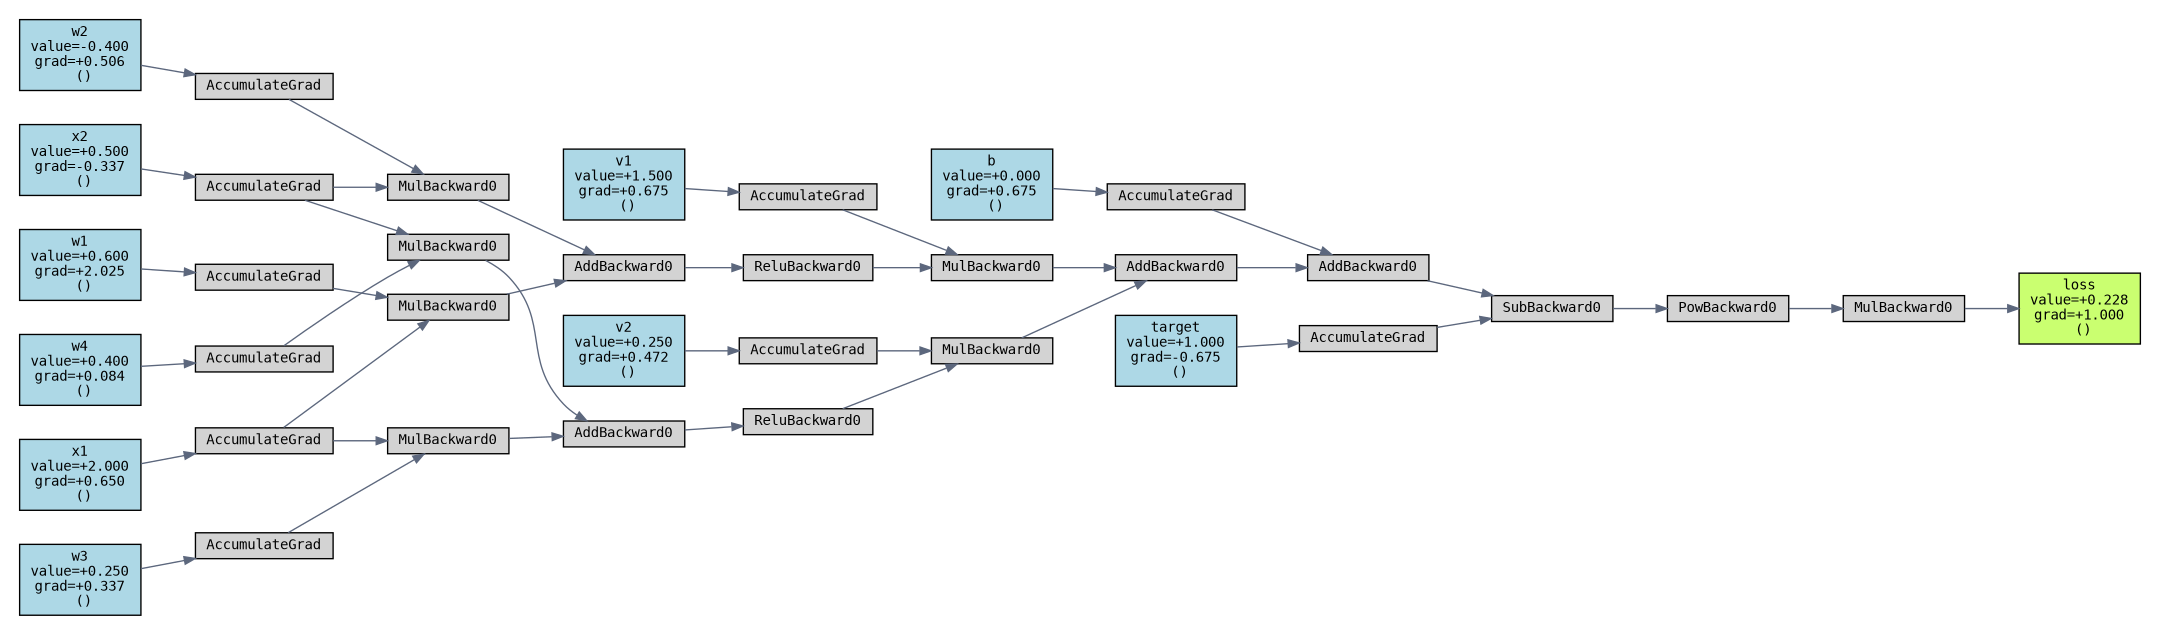

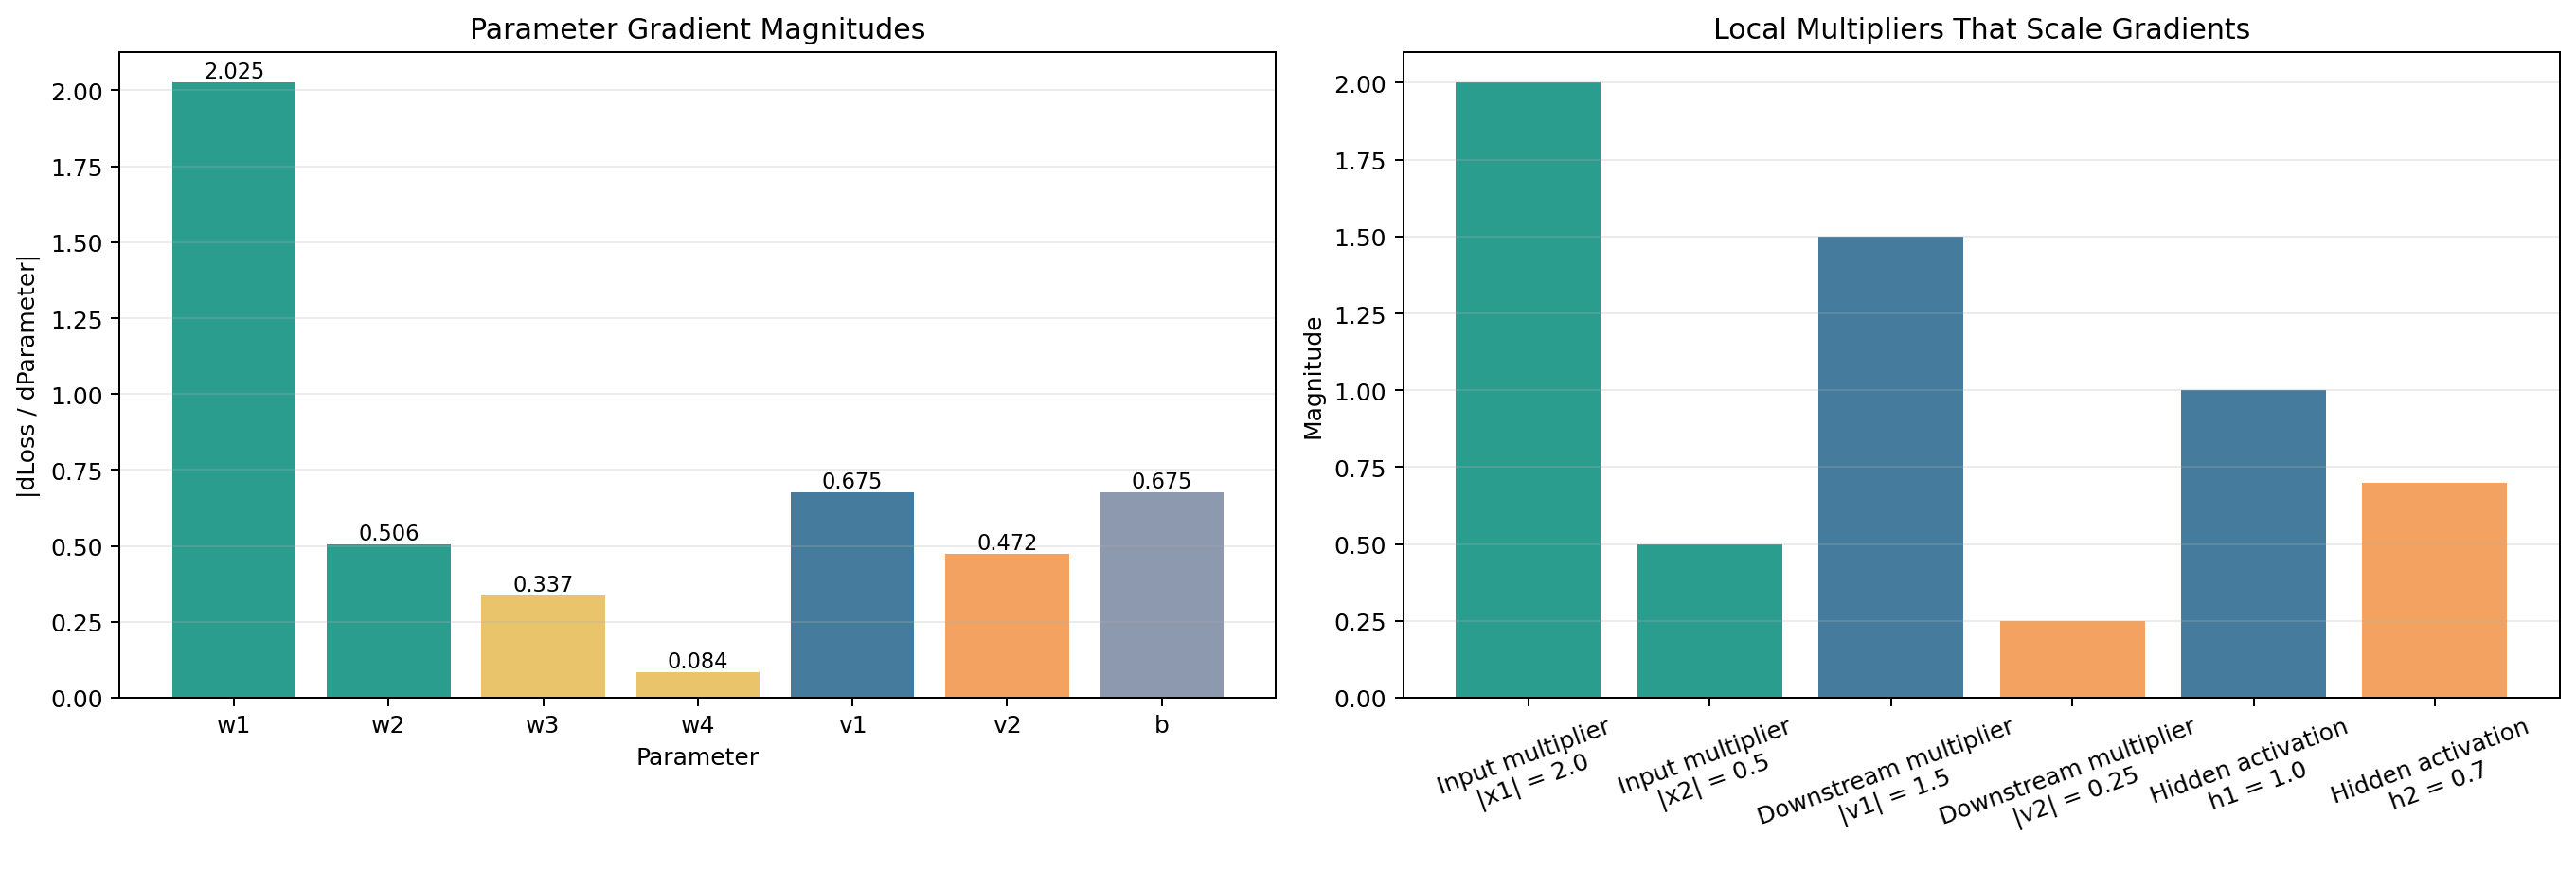

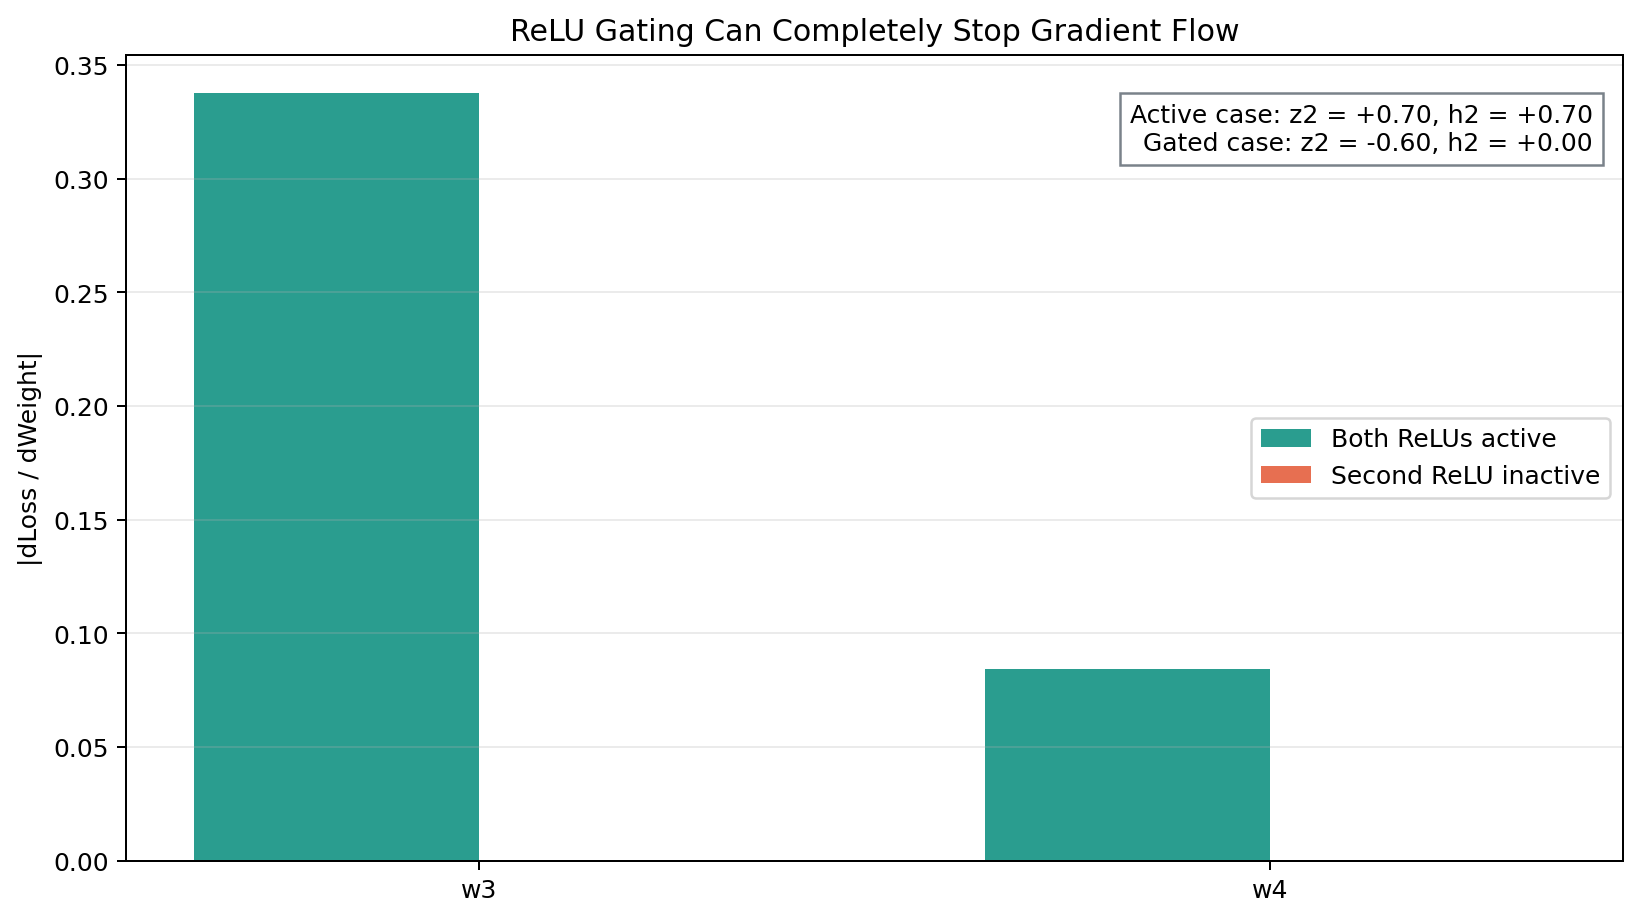

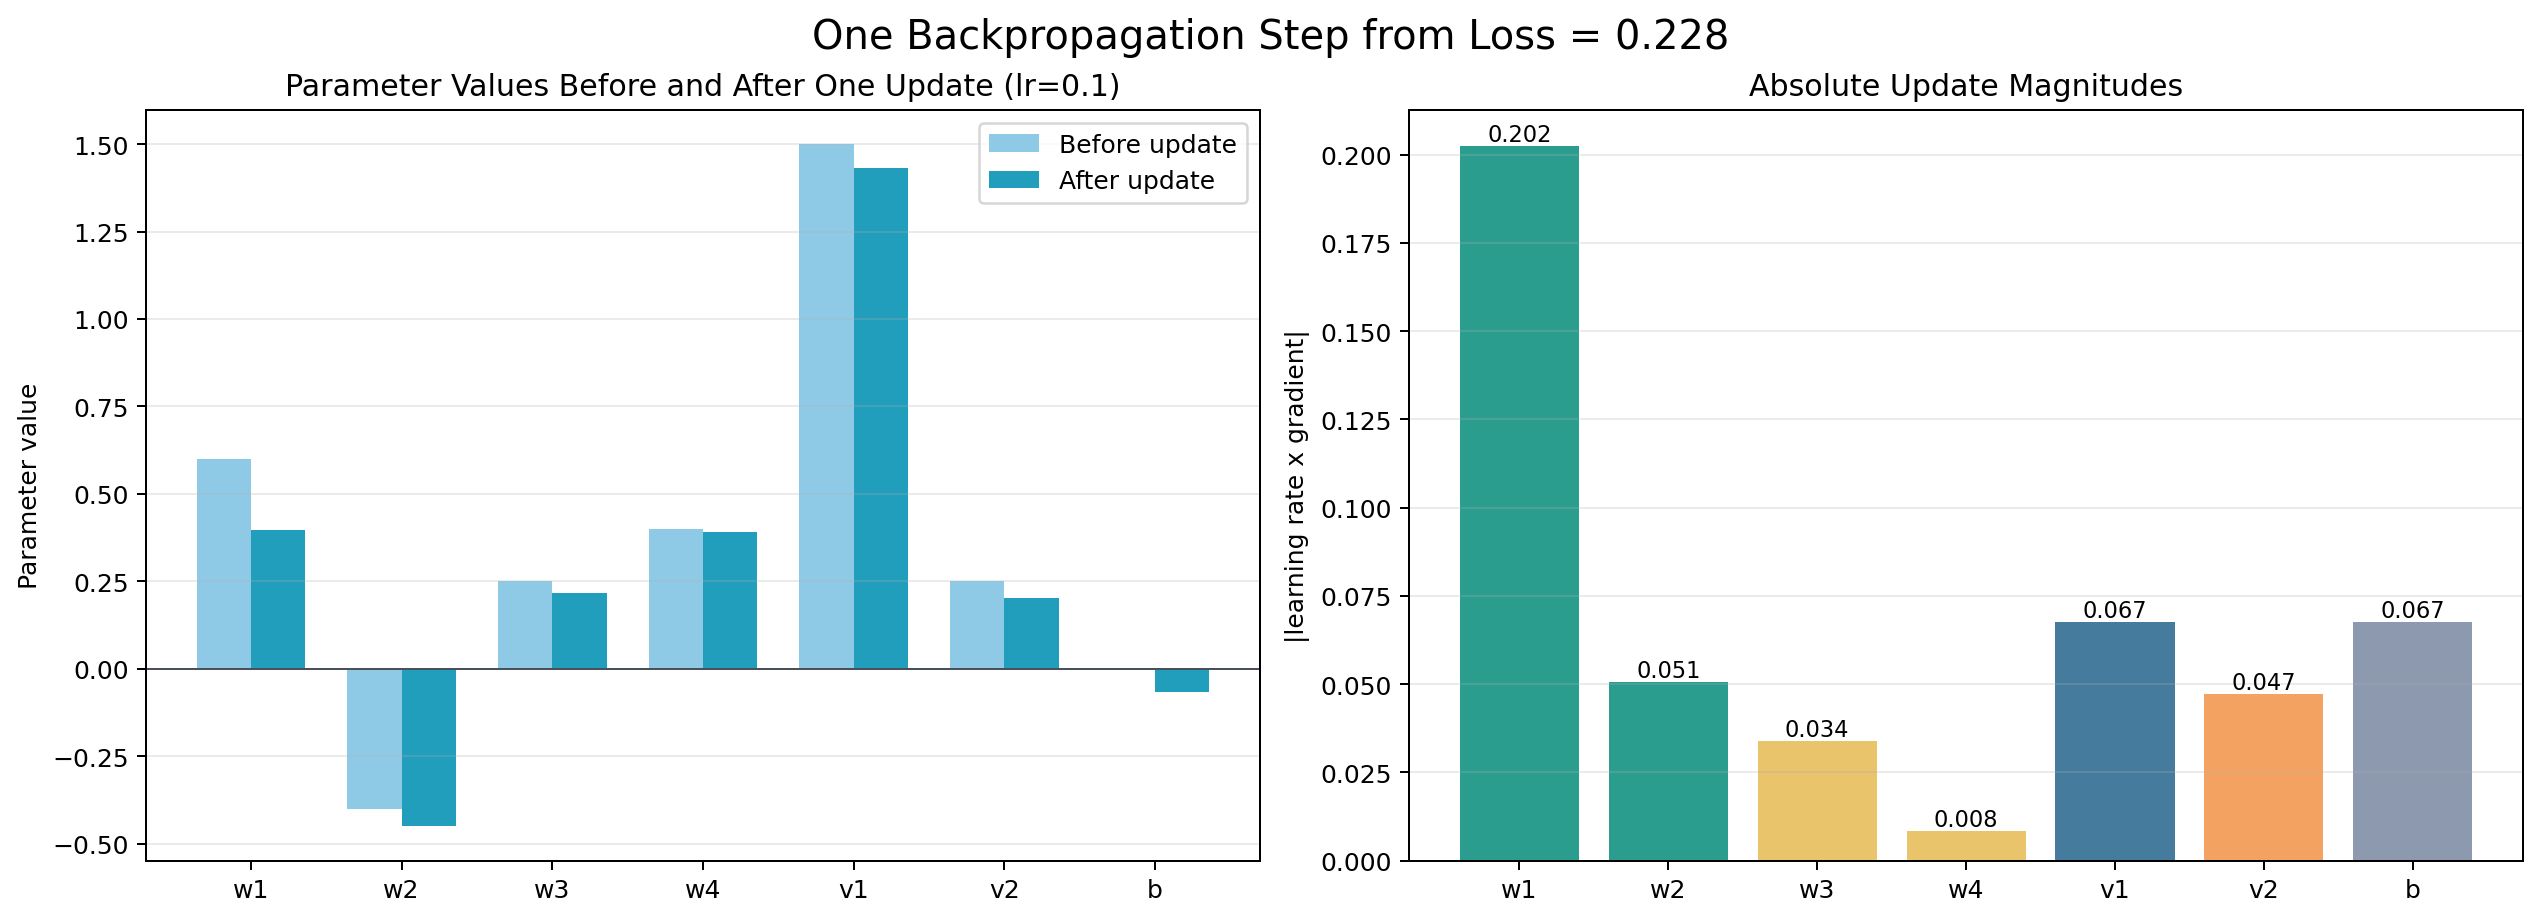

In [41]:
graph_output_dir = Path(OUTPUT_DIR) / "04_backpropagation_graph"
graph_output_dir.mkdir(parents=True, exist_ok=True)

parameters = make_parameters(device)
nodes = run_computation_graph(parameters, device)
visualize_autograd_graph(
    outputs=nodes["loss"],
    named_tensors={**parameters, **nodes},
    output_file=graph_output_dir / "01_computation_graph.png",
)
visualize_gradient_magnitudes(
    nodes, parameters, graph_output_dir / "02_gradient_magnitudes.png"
)
visualize_relu_gate_comparison(
    parameters, device, graph_output_dir / "03_relu_gate_comparison.png"
)
visualize_parameter_updates(
    nodes, parameters, 0.1, graph_output_dir / "04_parameter_updates.png"
)

for filename in [
    "01_computation_graph.png",
    "02_gradient_magnitudes.png",
    "03_relu_gate_comparison.png",
    "04_parameter_updates.png",
]:
    display(Image(filename=graph_output_dir / filename))

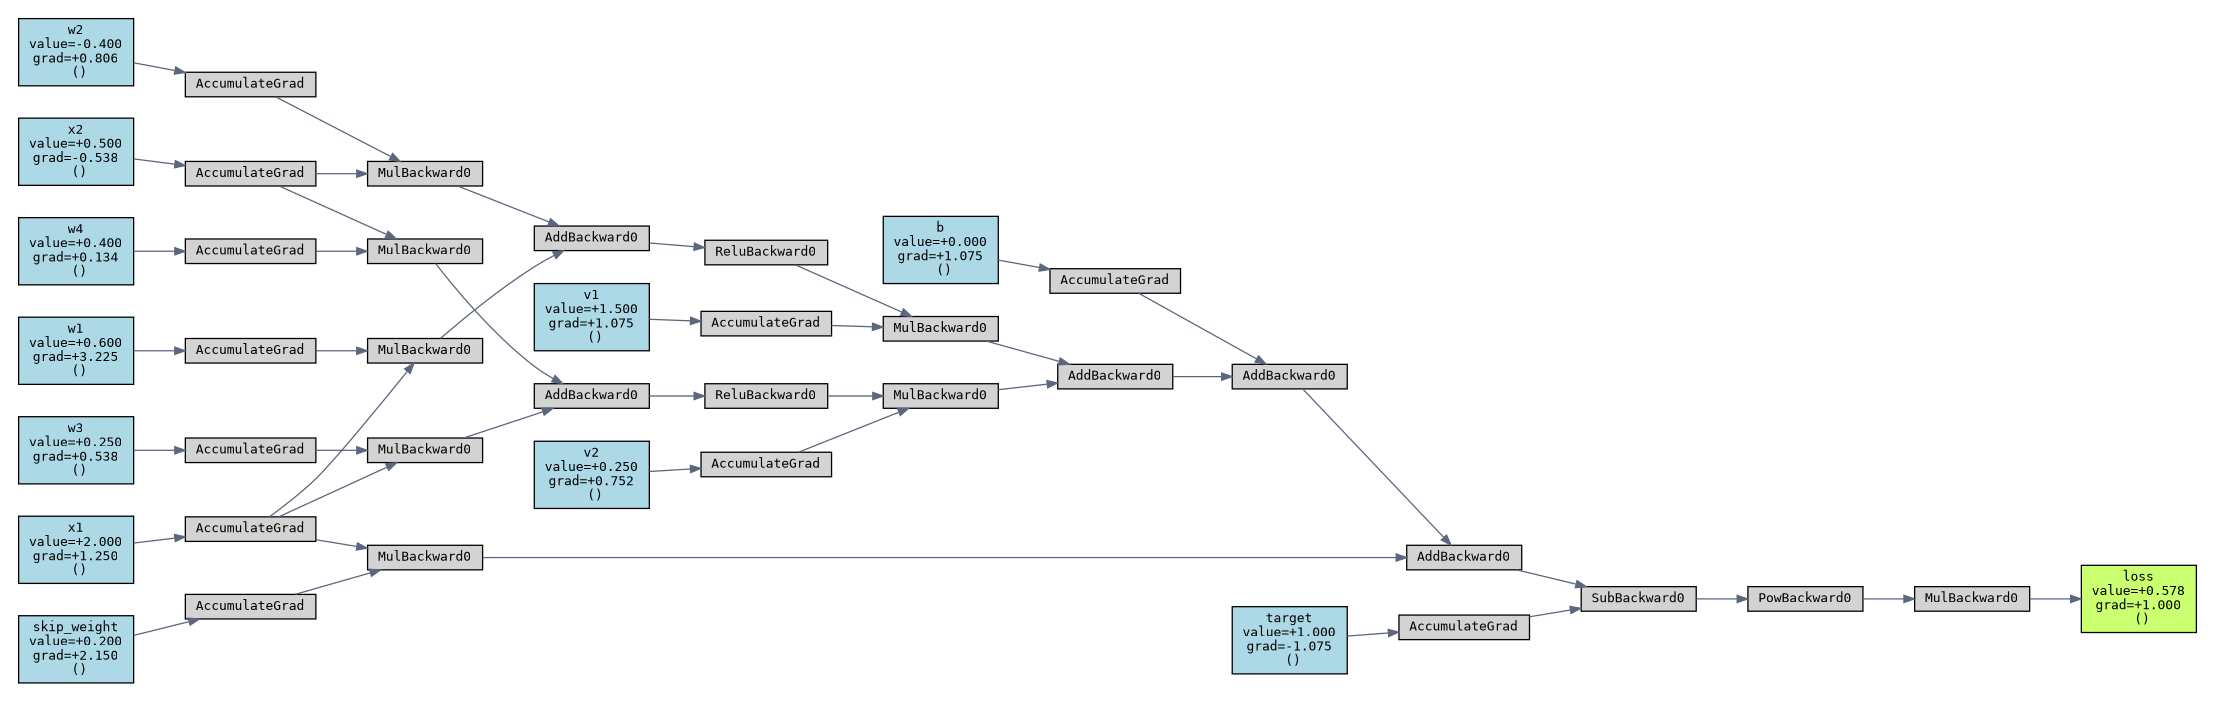

In [42]:
skip_weight = torch.tensor(0.20, device=device, requires_grad=True)
skip_parameters = make_parameters(device)
skip_nodes = run_computation_graph(skip_parameters, device, skip_weight=skip_weight)
visualize_autograd_graph(
    outputs=skip_nodes["loss"],
    named_tensors={**skip_parameters, "skip_weight": skip_weight, **skip_nodes},
    output_file=graph_output_dir / "05_skip_connection_graph.png",
)
display(Image(filename=graph_output_dir / "05_skip_connection_graph.png"))

# 05. Gradient Flow in CIFAR-10 Networks

The small graph showed that every local multiplier affects upstream gradients. In a deep neural network, this multiplication repeats across many layers.

Raw gradient norms grow with tensor size, so this section compares root-mean-square gradients. RMS reports the typical gradient magnitude per tensor element and permits more meaningful comparisons between differently sized layers.


## Gradient Diagnostic Helper

`run_diagnostic_backward` performs one backward pass on a fixed batch and records RMS weight gradients, RMS activation gradients, and zero-activation fractions.

In [43]:
def root_mean_square(tensor):
    return tensor.detach().square().mean().sqrt().item()


def run_diagnostic_backward(model, x, y, loss_fn):
    model = unwrap_model(model)
    model.eval()
    model.zero_grad(set_to_none=True)

    activations = []
    output = x
    for layer_id, layer in enumerate(model.layers):
        output = layer(output)
        if layer_id != len(model.layers) - 1:
            output = torch.relu(output)
            output.retain_grad()
            activations.append(output)

    loss = loss_fn(output, y)
    loss.backward()

    weight_gradient_rms = [
        root_mean_square(layer.w.grad)
        for layer in model.layers
    ]
    activation_gradient_rms = [
        root_mean_square(activation.grad)
        for activation in activations
    ]
    dead_activation_fraction = [
        (activation.detach() == 0).float().mean().item()
        for activation in activations
    ]
    final_weight_gradients = [
        layer.w.grad.detach().abs().flatten().cpu().numpy()
        for layer in model.layers
    ]

    model.zero_grad(set_to_none=True)
    return {
        "weight_gradient_rms": weight_gradient_rms,
        "activation_gradient_rms": activation_gradient_rms,
        "dead_activation_fraction": dead_activation_fraction,
        "final_weight_gradients": final_weight_gradients,
    }

## Training with Gradient Diagnostics

`train_with_gradient_diagnostics` adds one controlled diagnostic backward pass after every training epoch.

In [44]:
def train_with_gradient_diagnostics(
    model,
    trainloader,
    testloader,
    num_epochs,
    optimizer,
    device,
):
    loss_fn = nn.CrossEntropyLoss()
    analyzer = AccuracyAnalyzer()
    diagnostic_x, diagnostic_y = next(iter(testloader))
    diagnostic_x = diagnostic_x.to(device)
    diagnostic_y = diagnostic_y.to(device)

    history = {
        "epoch_losses": [],
        "test_accuracies": [],
        "weight_gradient_rms": [],
        "activation_gradient_rms": [],
        "dead_activation_fraction": [],
    }
    final_weight_gradients = None

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for x, y in trainloader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            scores = model(x)
            batch_loss = loss_fn(scores, y)

            optimizer.zero_grad(set_to_none=True)
            batch_loss.backward()
            optimizer.step()
            epoch_loss += batch_loss.item()

        diagnostics = run_diagnostic_backward(
            model,
            diagnostic_x,
            diagnostic_y,
            loss_fn,
        )
        epoch_loss /= len(trainloader)
        test_accuracy = analyzer.test(model, testloader, device)

        history["epoch_losses"].append(epoch_loss)
        history["test_accuracies"].append(test_accuracy)
        history["weight_gradient_rms"].append(diagnostics["weight_gradient_rms"])
        history["activation_gradient_rms"].append(diagnostics["activation_gradient_rms"])
        history["dead_activation_fraction"].append(diagnostics["dead_activation_fraction"])
        final_weight_gradients = diagnostics["final_weight_gradients"]

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs}: "
            f"loss={epoch_loss:.4f}, test_accuracy={test_accuracy:.4f}"
        )

    history["final_weight_gradients"] = final_weight_gradients
    return history

## Gradient-Flow Visualizers

These helpers show how gradient magnitude changes across layers and epochs and relate that evidence to training behavior.

### `visualize_gradient_heatmaps`

In [45]:
def visualize_gradient_heatmaps(history, architecture_name, output_file):
    figure, axes = plt.subplots(1, 3, figsize=(17, 5), layout="constrained")
    panels = [
        ("weight_gradient_rms", "Weight-gradient RMS", "magma", True),
        ("activation_gradient_rms", "Activation-gradient RMS", "magma", True),
        ("dead_activation_fraction", "Zero activation fraction", "YlGnBu", False),
    ]

    for axis, (key, title, color_map, use_log) in zip(axes, panels):
        values = np.asarray(history[key])
        display_values = np.log10(np.maximum(values, 1e-12)) if use_log else values
        image = axis.imshow(display_values.T, aspect="auto", cmap=color_map, origin="lower")
        axis.set_title(title + (" (log10)" if use_log else ""))
        axis.set_xlabel("Epoch")
        axis.set_ylabel("Layer")
        axis.set_xticks(range(len(values)), labels=range(1, len(values) + 1))
        axis.set_yticks(range(values.shape[1]), labels=range(1, values.shape[1] + 1))
        figure.colorbar(image, ax=axis, shrink=0.8)

    figure.suptitle(f"{architecture_name.title()} Network: Gradient Flow During Training", fontsize=16)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

### `visualize_final_gradient_distributions`

In [46]:
def visualize_final_gradient_distributions(history, architecture_name, output_file):
    figure, axis = plt.subplots(figsize=(10, 5), layout="constrained")
    zero_gradient_layers = []

    for layer_id, gradients in enumerate(history["final_weight_gradients"]):
        nonzero = gradients[gradients > 0]
        if len(nonzero) == 0:
            zero_gradient_layers.append(layer_id + 1)
            continue
        if len(nonzero) > 20000:
            nonzero = nonzero[:: max(1, len(nonzero) // 20000)]
        axis.hist(
            np.log10(np.maximum(nonzero, 1e-12)),
            bins=70,
            density=True,
            histtype="step",
            linewidth=1.8,
            label=f"Layer {layer_id + 1}",
        )

    if zero_gradient_layers:
        layer_names = ", ".join(str(layer_id) for layer_id in zero_gradient_layers)
        axis.axvline(
            -12,
            color="#222222",
            linestyle="--",
            linewidth=1.8,
            label=f"Layers {layer_names}: all zero",
        )

    axis.set_title(f"{architecture_name.title()} Network: Final Weight-Gradient Distributions")
    axis.set_xlabel("log10(|gradient|), zero gradients excluded")
    axis.set_ylabel("Density")
    axis.legend(ncol=2, fontsize=8)
    axis.grid(alpha=0.2)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

### `visualize_model_comparison`

In [47]:
def visualize_model_comparison(results, output_file):
    figure, axes = plt.subplots(1, 3, figsize=(16, 5), layout="constrained")

    for architecture_name, history in results.items():
        epochs = range(1, len(history["epoch_losses"]) + 1)
        color = COLORS[architecture_name]
        axes[0].plot(epochs, history["epoch_losses"], color=color, label=architecture_name.title())
        axes[1].plot(epochs, history["test_accuracies"], color=color, label=architecture_name.title())
        first_layer_gradients = np.asarray(history["weight_gradient_rms"])[:, 0]
        axes[2].plot(epochs, first_layer_gradients, color=color, label=architecture_name.title())

    axes[0].set_title("Training Loss")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[1].set_title("Test Accuracy")
    axes[1].set_ylabel("Accuracy")
    axes[2].set_title("First-Layer Weight-Gradient RMS")
    axes[2].set_ylabel("RMS gradient")
    axes[2].set_yscale("log")

    for axis in axes:
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.25)
        axis.legend()

    figure.suptitle("Shallow and Deep Networks Receive Different Gradient Signals", fontsize=16)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

In [ ]:
GRADIENT_ARCHITECTURES = {
    "shallow": [512],
    "deep": [512, 512, 512, 512, 512, 512],
}

COLORS = {
    "shallow": "#287271",
    "deep": "#E76F51",
}

def compare_gradient_flow(architectures, num_epochs=20):
    results = {}
    for architecture_name, hidden_layer_sizes in architectures.items():
        set_seed(GLOBAL_SEED)
        model = NeuralNetwork(
            3 * 32 * 32,
            len(CIFAR10_CLASS_NAMES),
            hidden_layer_sizes,
        ).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        print(f"\nTraining {architecture_name}: {hidden_layer_sizes}")
        results[architecture_name] = train_with_gradient_diagnostics(
            model, trainloader, testloader, num_epochs, optimizer, device
        )
    return results

## Compare Shallow and Deep Networks



Training shallow: [512]
Epoch 01/20: loss=1.9335, test_accuracy=0.3608
Epoch 02/20: loss=1.7403, test_accuracy=0.3927
Epoch 03/20: loss=1.6539, test_accuracy=0.4118
Epoch 04/20: loss=1.5946, test_accuracy=0.4420
Epoch 05/20: loss=1.5581, test_accuracy=0.4549
Epoch 06/20: loss=1.5254, test_accuracy=0.4422
Epoch 07/20: loss=1.4943, test_accuracy=0.4486
Epoch 08/20: loss=1.4651, test_accuracy=0.4692
Epoch 09/20: loss=1.4410, test_accuracy=0.4794
Epoch 10/20: loss=1.4190, test_accuracy=0.4855
Epoch 11/20: loss=1.4028, test_accuracy=0.4807
Epoch 12/20: loss=1.3934, test_accuracy=0.4842
Epoch 13/20: loss=1.3639, test_accuracy=0.4879
Epoch 14/20: loss=1.3614, test_accuracy=0.4998
Epoch 15/20: loss=1.3392, test_accuracy=0.5018
Epoch 16/20: loss=1.3263, test_accuracy=0.4987
Epoch 17/20: loss=1.3037, test_accuracy=0.5196
Epoch 18/20: loss=1.2929, test_accuracy=0.5062
Epoch 19/20: loss=1.2809, test_accuracy=0.4897
Epoch 20/20: loss=1.2689, test_accuracy=0.5093

Training deep: [512, 512, 512, 512

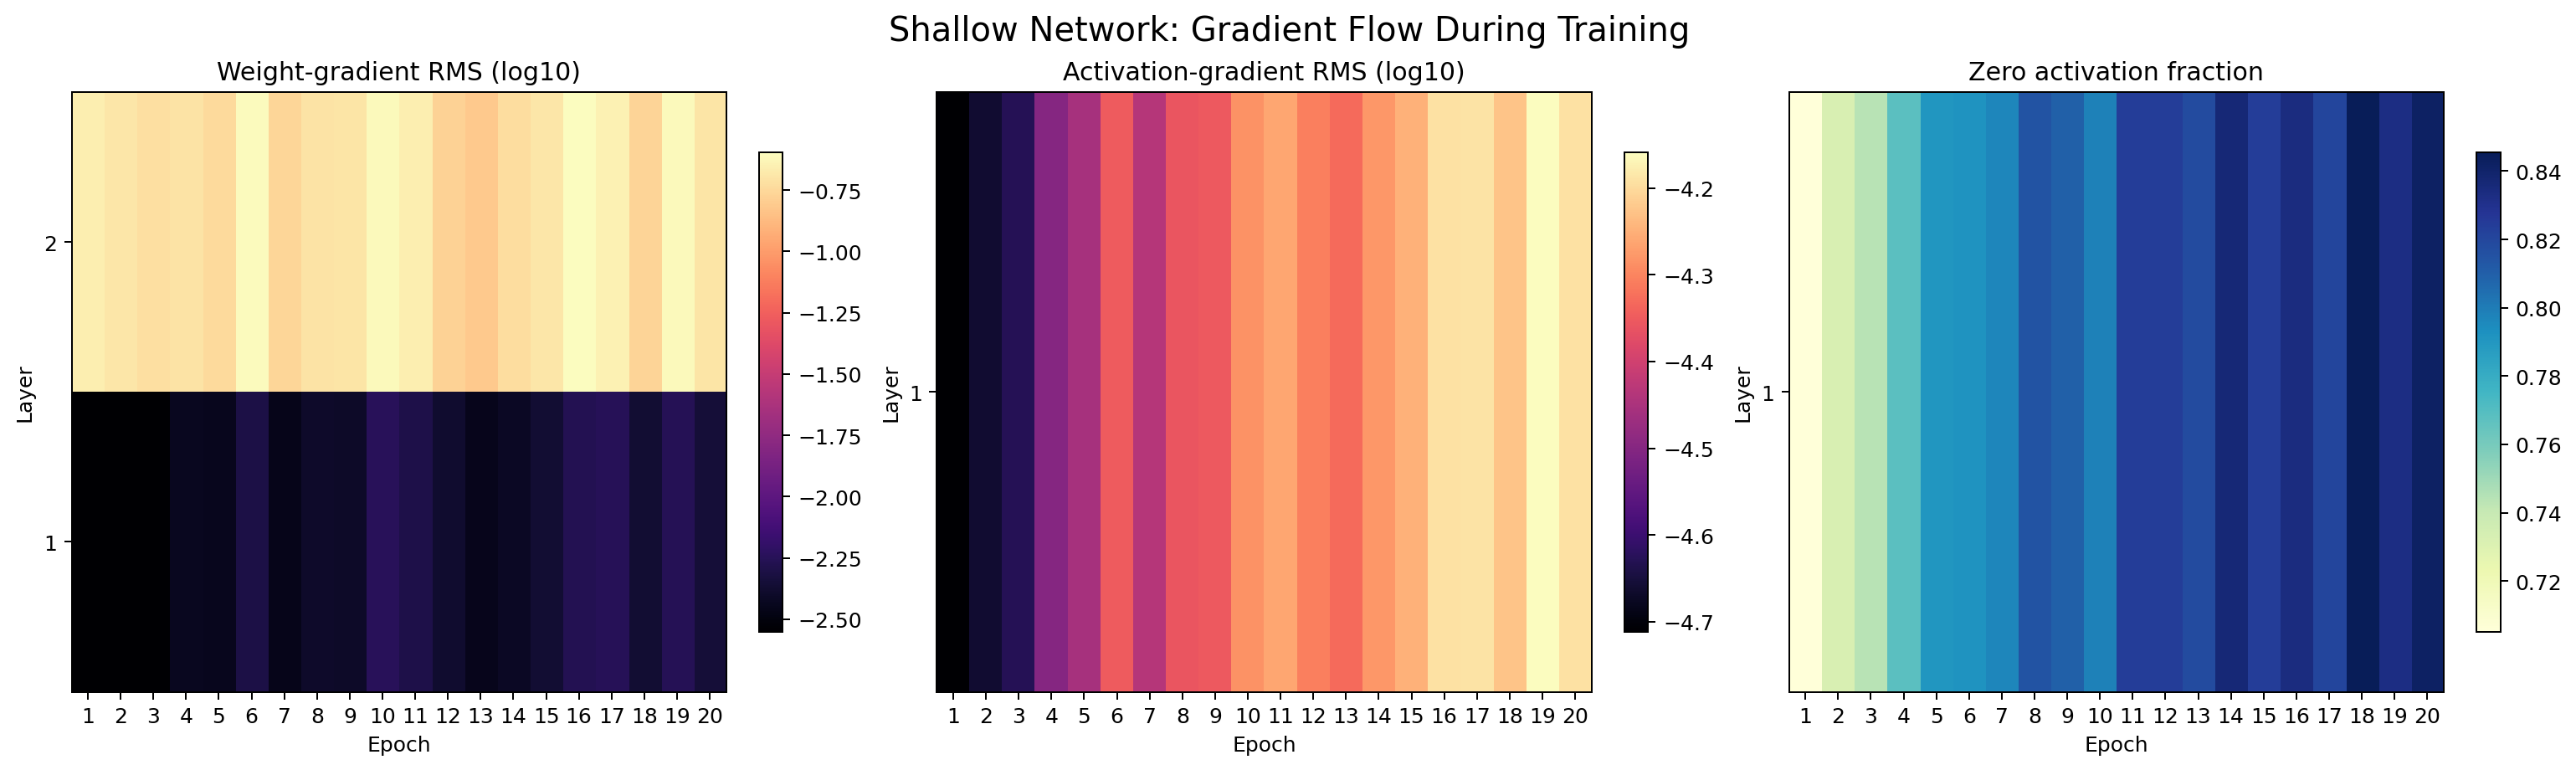

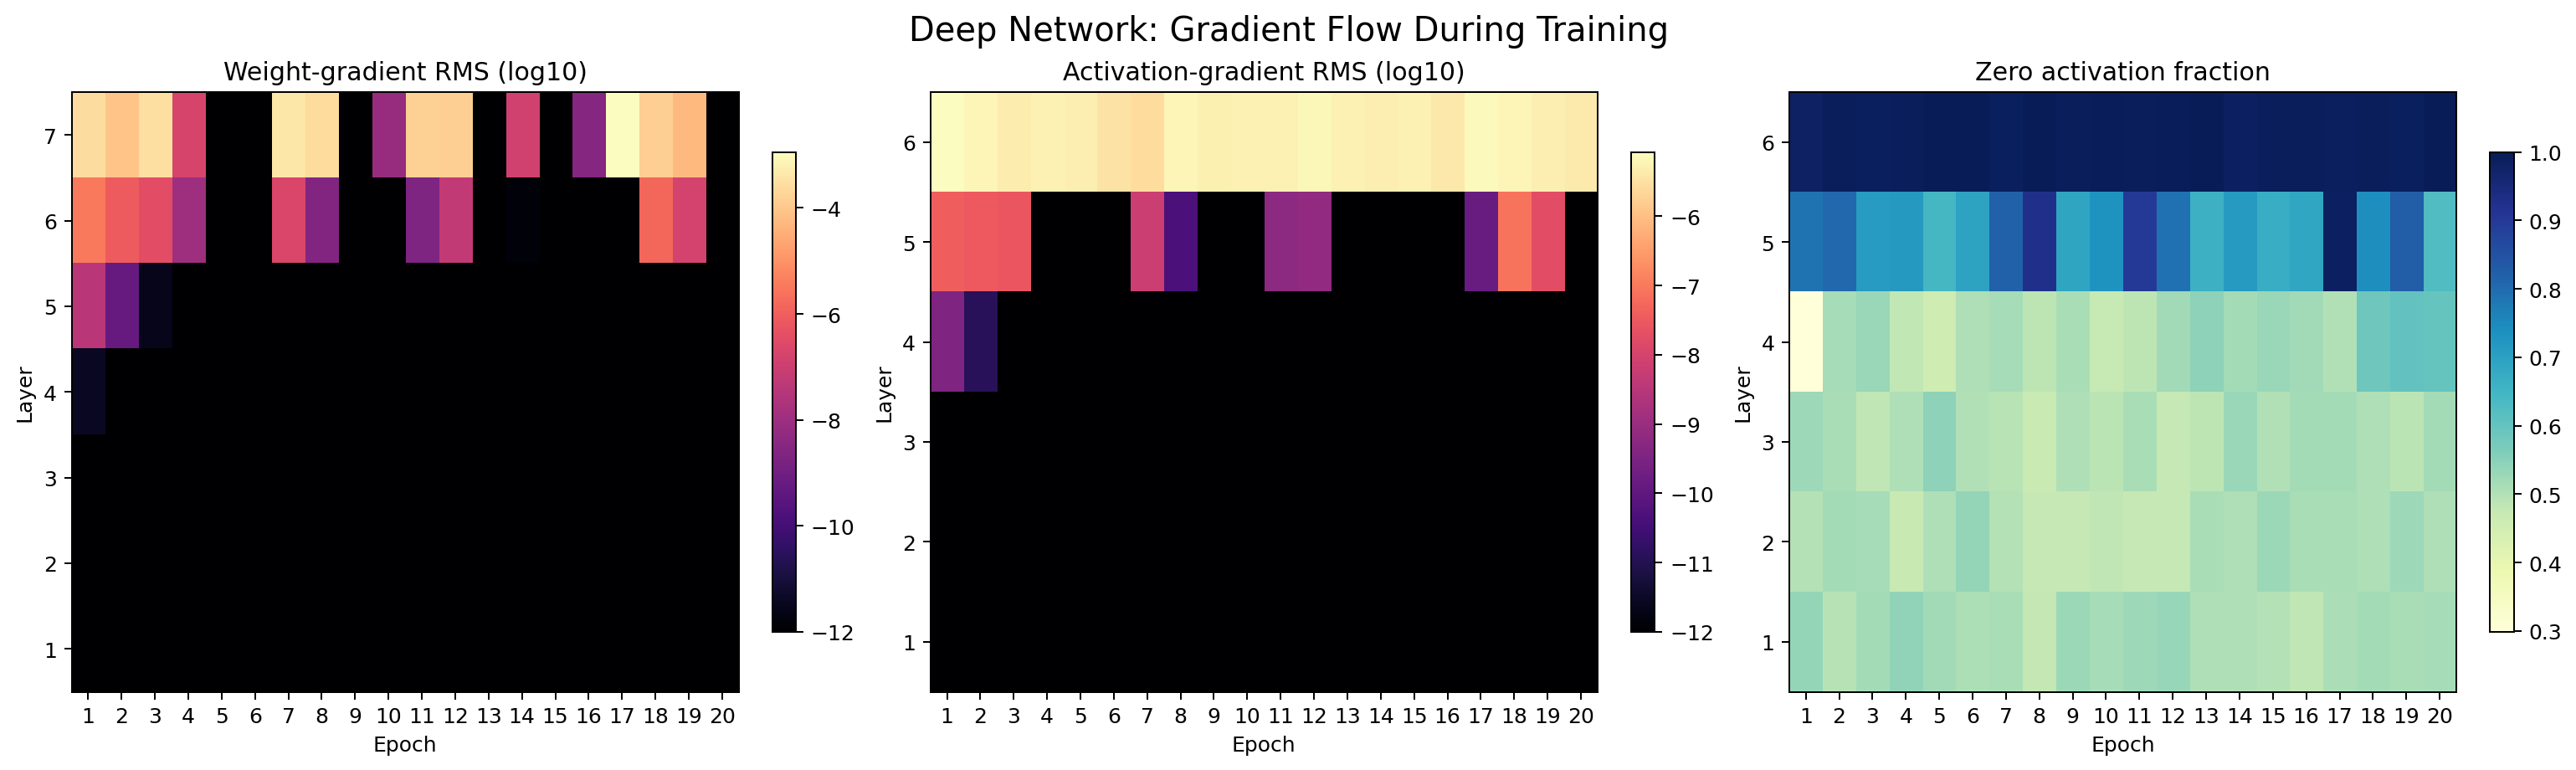

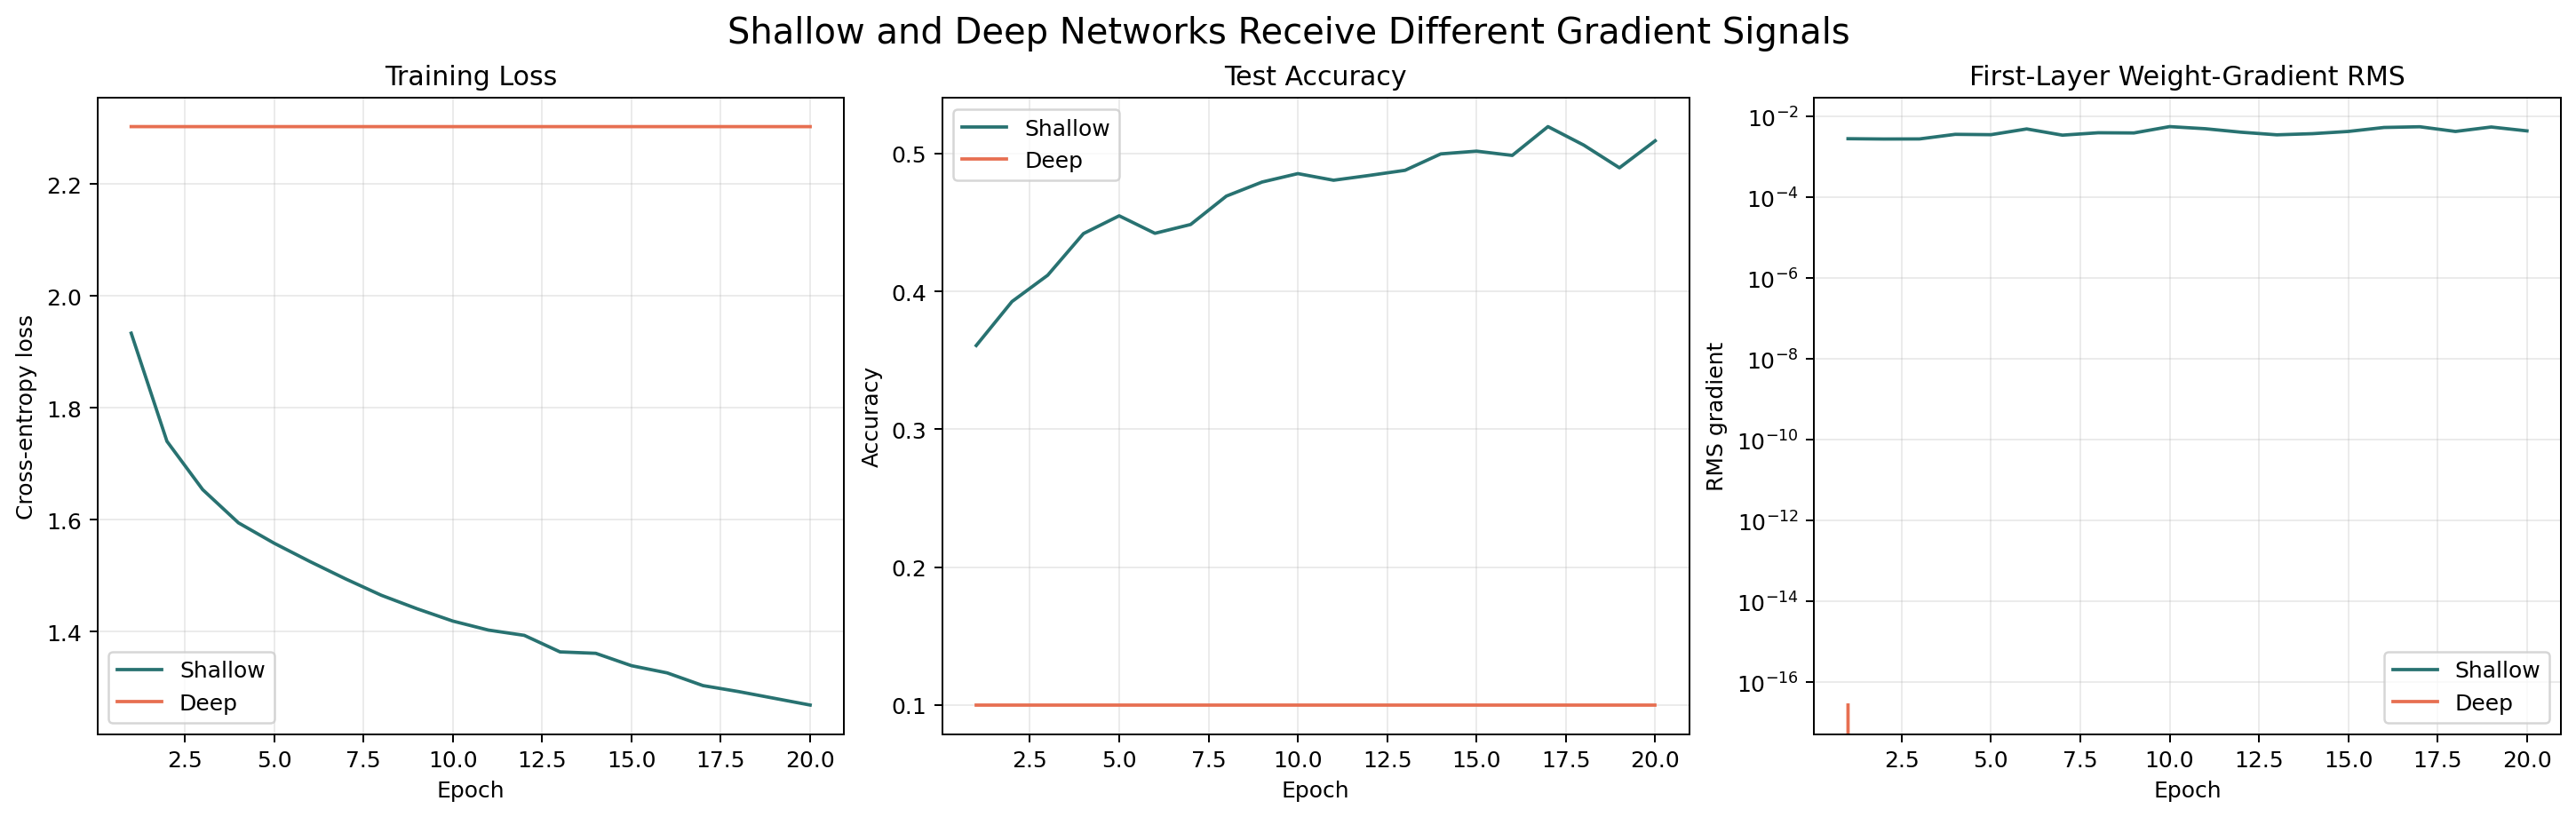

In [49]:
gradient_results = compare_gradient_flow(GRADIENT_ARCHITECTURES)

gradient_output_dir = Path(OUTPUT_DIR) / "05_gradient_flow"
gradient_output_dir.mkdir(parents=True, exist_ok=True)
for architecture_name, history in gradient_results.items():
    visualize_gradient_heatmaps(
        history,
        architecture_name,
        gradient_output_dir / f"{architecture_name}_gradient_heatmaps.png",
    )
    display(Image(filename=gradient_output_dir / f"{architecture_name}_gradient_heatmaps.png"))

visualize_model_comparison(
    gradient_results,
    gradient_output_dir / "shallow_deep_comparison.png",
)
display(Image(filename=gradient_output_dir / "shallow_deep_comparison.png"))

In [50]:
for model_name, history in gradient_results.items():
    final_gradients = np.asarray(history["weight_gradient_rms"][-1])
    print(model_name, "strongest layer:", final_gradients.argmax() + 1)
    print(model_name, "weakest layer:", final_gradients.argmin() + 1)

shallow strongest layer: 2
shallow weakest layer: 1
deep strongest layer: 1
deep weakest layer: 1


# 06. Designing Your Own Network

You will define one candidate architecture and compare it against a fixed baseline under the same training conditions.


In [51]:
COLORS = {
    "baseline": "#4C78A8",
    "candidate": "#E45756",
}

In [52]:
def visualize_integrated_comparison(results, output_file):
    figure, axes = plt.subplots(1, 3, figsize=(16, 5), layout="constrained")

    for model_name, result in results.items():
        history = result["history"]
        epochs = range(1, len(history["epoch_losses"]) + 1)
        color = COLORS[model_name]
        axes[0].plot(epochs, history["epoch_losses"], color=color, label=model_name.title())
        axes[1].plot(epochs, history["test_accuracies"], color=color, label=model_name.title())
        axes[2].plot(
            range(1, len(history["weight_gradient_rms"][-1]) + 1),
            history["weight_gradient_rms"][-1],
            marker="o",
            color=color,
            label=model_name.title(),
        )

    axes[0].set_title("Training Loss")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[1].set_title("Test Accuracy")
    axes[1].set_ylabel("Accuracy")
    axes[2].set_title("Final Weight-Gradient Flow")
    axes[2].set_ylabel("RMS gradient")
    axes[2].set_yscale("log")

    for axis in axes:
        axis.set_xlabel("Epoch" if axis is not axes[2] else "Layer")
        axis.grid(alpha=0.25)
        axis.legend()

    figure.suptitle("Final CIFAR-10 Investigation: Baseline vs Candidate", fontsize=16)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

In [53]:
def run_final_investigation(architectures, num_epochs=20):
    results = {}
    for model_name, hidden_layer_sizes in architectures.items():
        set_seed(GLOBAL_SEED)
        model = NeuralNetwork(
            3 * 32 * 32,
            len(CIFAR10_CLASS_NAMES),
            hidden_layer_sizes,
        ).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        history = train_with_gradient_diagnostics(
            model, trainloader, testloader, num_epochs, optimizer, device
        )
        results[model_name] = {
            "model": model,
            "hidden_layer_sizes": hidden_layer_sizes,
            "num_parameters": count_parameters(model),
            "history": history,
        }
    return results

In [54]:
candidate_hidden_layer_sizes = [256, 512, 512, 256]
final_architectures = {
    "baseline": [256, 256, 256],
    "candidate": candidate_hidden_layer_sizes,
}

The candidate's wider layers increase capacity to learn complex features and the funnel shape gives optimization by providing a balanced path for gradient flow. I expect it to outperform the baseline in accuracy without hitting vanishing gradient issues of deeper models.

In [ ]:
final_results = run_final_investigation(final_architectures)

final_output_dir = Path(OUTPUT_DIR) / "06_final_investigation"
final_output_dir.mkdir(parents=True, exist_ok=True)
visualize_integrated_comparison(
    final_results,
    final_output_dir / "integrated_comparison.png",
)
display(Image(filename=final_output_dir / "integrated_comparison.png"))

Epoch 01/20: loss=2.0859, test_accuracy=0.2525
Epoch 02/20: loss=1.9179, test_accuracy=0.3184
Epoch 03/20: loss=1.8042, test_accuracy=0.3652
Epoch 04/20: loss=1.7352, test_accuracy=0.3788
Epoch 05/20: loss=1.6644, test_accuracy=0.4134
Epoch 06/20: loss=1.6112, test_accuracy=0.4308
Epoch 07/20: loss=1.5724, test_accuracy=0.4464
Epoch 08/20: loss=1.5312, test_accuracy=0.4456
Epoch 09/20: loss=1.4985, test_accuracy=0.4664
Epoch 10/20: loss=1.4799, test_accuracy=0.4669
Epoch 11/20: loss=1.4518, test_accuracy=0.4780
Epoch 12/20: loss=1.4303, test_accuracy=0.4849
Epoch 13/20: loss=1.4157, test_accuracy=0.4810
Epoch 14/20: loss=1.3841, test_accuracy=0.4755
Epoch 15/20: loss=1.3648, test_accuracy=0.4945
Epoch 16/20: loss=1.3484, test_accuracy=0.4912
Epoch 17/20: loss=1.3308, test_accuracy=0.5153
Epoch 18/20: loss=1.3184, test_accuracy=0.5041
Epoch 19/20: loss=1.2946, test_accuracy=0.4956
Epoch 20/20: loss=1.2803, test_accuracy=0.5012
